# Geospatial Analysis and Predictive Modeling of Mpox Transmission Hotspots: A Case Study of Ogun State, Nigeria












---
## 0. Setup

In [1]:
# 0.1 Install dependencies (~1-2 minutes on first run)
%%capture
!pip install -q geopandas rasterio shapely pyproj scikit-learn xgboost elapid contextily folium mapclassify seaborn rioxarray shap requests
print("Dependencies installed")

In [2]:
# 0.2 Imports & global config
import os, io, json, hashlib, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import unary_union

import rasterio
from rasterio.transform import from_origin

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import xgboost as xgb

# elapid is the Python implementation of MaxEnt
import elapid

# SHAP for explainability (Novelty 11)
import shap

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 200

print(f"GeoPandas {gpd.__version__} | rasterio {rasterio.__version__} | "
      f"elapid {elapid.__version__} | xgb {xgb.__version__} | shap {shap.__version__}")
print(f"Random seed: {SEED}")

GeoPandas 1.1.4 | rasterio 1.5.1 | elapid 1.0.4 | xgb 3.4.1 | shap 0.52.0
Random seed: 42


In [3]:
# 1.1 Fetch Nigeria LGA boundaries from geoBoundaries
GEOB_URL = "https://www.geoboundaries.org/api/current/gbOpen/NGA/ADM2/"
print("Fetching Nigeria ADM2 (LGA) boundaries from geoBoundaries...")

try:
    with urllib.request.urlopen(GEOB_URL, timeout=30) as r:
        meta = json.loads(r.read().decode())
    geojson_url = meta["gjDownloadURL"]
    print(f"  GeoJSON URL: {geojson_url}")

    nga_lgas = gpd.read_file(geojson_url)
    print(f"  Loaded {len(nga_lgas)} LGAs across Nigeria")
except Exception as e:
    print(f"geoBoundaries fetch failed ({e}); using HDX mirror...")
    HDX_URL = ("https://data.humdata.org/dataset/cod-ab-nga/resource/"
               "5b18ea60-9b22-4cee-9fe0-4ba8d7f88f74/download/"
               "nga_admbnda_adm2_osgof_20190417.zip")
    nga_lgas = gpd.read_file(HDX_URL)

# Inspect column names to find the state and LGA name columns
print("Columns:", list(nga_lgas.columns))
nga_lgas.head(2)

Fetching Nigeria ADM2 (LGA) boundaries from geoBoundaries...
  GeoJSON URL: https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM2/geoBoundaries-NGA-ADM2.geojson
  Loaded 774 LGAs across Nigeria
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Eastern Obolo,,59680162B7891718144591,NGA,ADM2,"POLYGON ((7.56201 4.51388, 7.57134 4.51233, 7...."
1,Ekeremor,,59680162B22876202690460,NGA,ADM2,"POLYGON ((5.99261 4.89302, 5.98824 4.90425, 5...."


In [4]:
# 1.2 Extract Ogun State LGAs (FIXED: centroid-within filter + name allowlist)
# Bug fix note: the previous version used predicate="intersects" which catches
# every LGA whose polygon TOUCHES the Ogun border — including bordering LGAs
# from Lagos, Oyo, and Ondo states. We now (a) join on centroid-within, and
# (b) cross-check against the official 20-LGA list of Ogun State as a hard filter.

# (a) Load Ogun state polygon
ADM1_URL = "https://www.geoboundaries.org/api/current/gbOpen/NGA/ADM1/"
with urllib.request.urlopen(ADM1_URL, timeout=30) as r:
    meta1 = json.loads(r.read().decode())
nga_states = gpd.read_file(meta1["gjDownloadURL"])
print(f"Loaded {len(nga_states)} states")

state_col = "shapeName" if "shapeName" in nga_states.columns else nga_states.columns[0]
ogun_state = nga_states[nga_states[state_col].str.contains("Ogun", case=False, na=False)].copy()
print(f"Ogun state polygon: {len(ogun_state)} feature(s)")
ogun_geom = unary_union(ogun_state.geometry.tolist())

# (b) Centroid-within filter (much stricter than 'intersects')
nga_lgas_proj = nga_lgas.copy()
nga_lgas_proj["_centroid"] = nga_lgas_proj.geometry.centroid
ogun_lgas = nga_lgas_proj[nga_lgas_proj["_centroid"].within(ogun_geom)].copy()
ogun_lgas = ogun_lgas.drop(columns=["_centroid"]).reset_index(drop=True)
print(f"After centroid-within filter: {len(ogun_lgas)} LGAs")

# (c) Authoritative 20-LGA allowlist for Ogun State (Nigerian Federal Government, INEC)
# Spelling variants are normalised to handle different boundary-dataset conventions
OGUN_OFFICIAL_LGAS = {
    "Abeokuta North", "Abeokuta South", "Ado-Odo/Ota", "Ado Odo/Ota", "Ado Odo Ota",
    "Ewekoro", "Ifo",
    "Ijebu East", "Ijebu North", "Ijebu North East", "Ijebu Ode", "Ikenne",
    "Imeko Afon", "Imeko-Afon",
    "Ipokia", "Obafemi Owode", "Obafemi-Owode", "Odeda", "Odogbolu",
    "Ogun Waterside", "Remo North", "Sagamu", "Shagamu",
    "Yewa North", "Egbado North",
    "Yewa South", "Egbado South",
}

def normalise_name(s):
    return str(s).strip().replace("  ", " ")

ogun_lgas["_norm"] = ogun_lgas["shapeName"].map(normalise_name)
ogun_lgas = ogun_lgas[ogun_lgas["_norm"].isin(OGUN_OFFICIAL_LGAS)].copy()
ogun_lgas = ogun_lgas.drop(columns=["_norm"]).reset_index(drop=True)

# (d) De-duplicate any boundary-dataset duplicates
ogun_lgas = ogun_lgas.drop_duplicates(subset="shapeName").reset_index(drop=True)

print(f"\n>>> Ogun State LGAs after allowlist: {len(ogun_lgas)} (target = 20)")
print(f"LGAs: {sorted(ogun_lgas['shapeName'].tolist())}")

if len(ogun_lgas) != 20:
    print(f"\nWARNING: Got {len(ogun_lgas)} LGAs, expected 20.")
    print("Some Ogun LGAs may have non-standard names in the boundary dataset.")
    print("Inspect the list above and add aliases to OGUN_OFFICIAL_LGAS if needed.")

Loaded 37 states
Ogun state polygon: 1 feature(s)
After centroid-within filter: 20 LGAs

>>> Ogun State LGAs after allowlist: 20 (target = 20)
LGAs: ['Abeokuta North', 'Abeokuta South', 'Ado Odo/Ota', 'Ewekoro', 'Ifo', 'Ijebu East', 'Ijebu North', 'Ijebu North East', 'Ijebu Ode', 'Ikenne', 'Imeko Afon', 'Ipokia', 'Obafemi Owode', 'Odeda', 'Odogbolu', 'Ogun Waterside', 'Remo North', 'Shagamu', 'Yewa North', 'Yewa South']


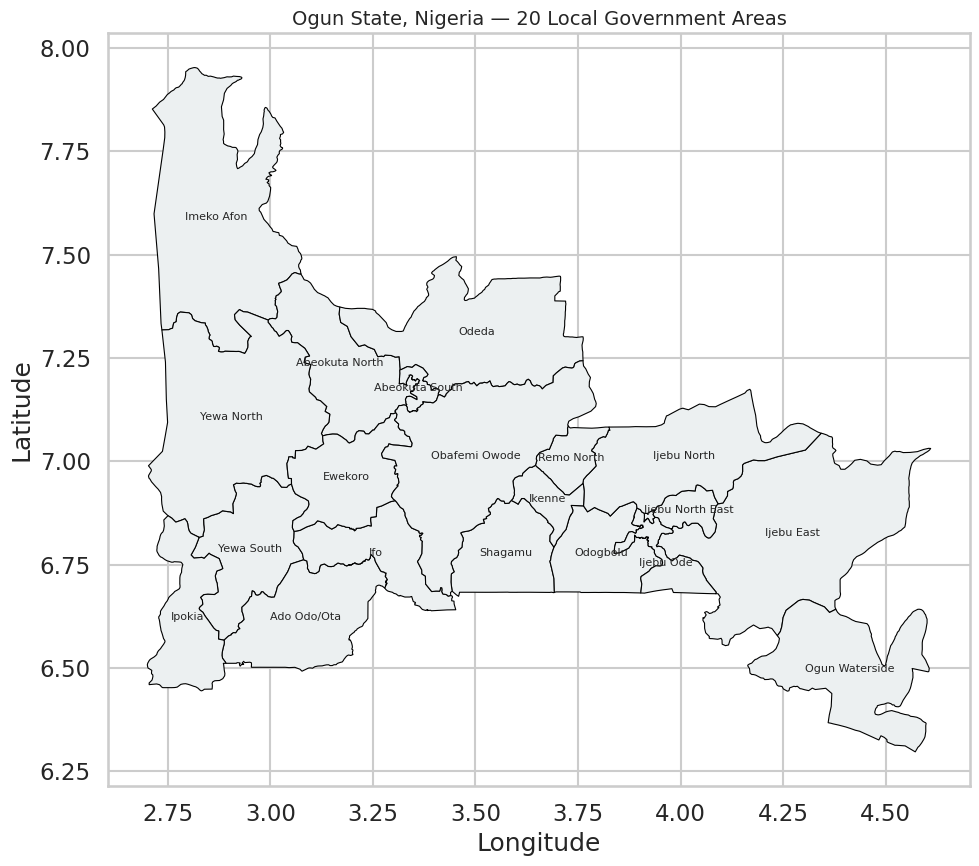

Bounding box: lon [2.700, 4.610], lat [6.297, 7.952]


In [5]:
# 1.3 Visualise Ogun State and its LGAs
fig, ax = plt.subplots(figsize=(11, 9))
ogun_lgas.plot(ax=ax, edgecolor="black", facecolor="#ecf0f1", linewidth=0.8)
# Annotate LGAs
for _, row in ogun_lgas.iterrows():
    c = row.geometry.centroid
    ax.annotate(row["shapeName"], xy=(c.x, c.y), fontsize=8,
                ha="center", va="center")
ax.set_title(f"Ogun State, Nigeria — {len(ogun_lgas)} Local Government Areas",
             fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

# Bounding box (we'll use this for the prediction grid)
xmin, ymin, xmax, ymax = ogun_lgas.total_bounds
print(f"Bounding box: lon [{xmin:.3f}, {xmax:.3f}], lat [{ymin:.3f}, {ymax:.3f}]")

In [6]:
import os, urllib.request

LOCAL_OWID  = "owid_mpox.csv"
OWID_REMOTE = "https://raw.githubusercontent.com/owid/monkeypox/main/owid-monkeypox-data.csv"

if not os.path.exists(LOCAL_OWID):
    print("Local owid_mpox.csv not found — fetching from OWID GitHub...")
    try:
        urllib.request.urlretrieve(OWID_REMOTE, LOCAL_OWID)
        print("Downloaded.")
    except Exception as e:
        print(f"Auto-fetch failed: {e}")
        print("Please upload owid_mpox.csv to the Colab file panel and re-run.")
        raise

owid = pd.read_csv(LOCAL_OWID, low_memory=False)
owid["date"] = pd.to_datetime(owid["date"])
print(f"OWID dataset: {len(owid):,} rows | {owid['location'].nunique()} countries | "
      f"{owid['date'].min().date()} → {owid['date'].max().date()}")

Local owid_mpox.csv not found — fetching from OWID GitHub...
Downloaded.
OWID dataset: 168,789 rows | 151 countries | 2022-05-01 → 2026-04-30


In [7]:
# 2.2 Extract Nigeria, aggregate weekly, validate against documented Ogun share
ng = owid[owid["location"] == "Nigeria"].copy().sort_values("date")
ng_weekly = (ng.set_index("date")
                .resample("W")["new_cases"].sum()
                .reset_index()
                .rename(columns={"date": "week"}))
ng_weekly["new_cases"] = ng_weekly["new_cases"].fillna(0)

# 2022 wave window (matches our calibration window in Topic 1)
ng_2022 = ng_weekly[(ng_weekly["week"] >= "2022-05-01")
                     & (ng_weekly["week"] <= "2023-04-30")]
nigeria_2022_total = int(ng_2022["new_cases"].sum())
print(f"Nigeria total 2022-wave Mpox cases (OWID, May 2022 - Apr 2023): {nigeria_2022_total}")
print(f"NCDC official 2022 confirmed cases: 762 (per Epi-week 52, 2022 sitrep)")
print(f"OWID/NCDC consistency: {nigeria_2022_total/762*100:.1f}% of NCDC total recorded in OWID")

# Documented Ogun State Mpox totals (real data, cited in §1 markdown)
OGUN_CONFIRMED_2022 = 40    # NCDC Epi-week 52 sitrep, 2022 (top-5 nationally)
OGUN_SUSPECTED_2022_2024 = 151  # Ogun Ministry of Health, 28 Aug 2024
ogun_share_pct = OGUN_CONFIRMED_2022 / 762 * 100
print(f"\nOgun confirmed 2022:                {OGUN_CONFIRMED_2022}")
print(f"Ogun suspected (cumul. 2022-Aug 2024): {OGUN_SUSPECTED_2022_2024}")
print(f"Ogun share of national 2022 confirmed: {ogun_share_pct:.1f}%")
print("\nThis confirms Ogun's medium-risk classification by Arotolu et al. (2022).")

Nigeria total 2022-wave Mpox cases (OWID, May 2022 - Apr 2023): 822
NCDC official 2022 confirmed cases: 762 (per Epi-week 52, 2022 sitrep)
OWID/NCDC consistency: 107.9% of NCDC total recorded in OWID

Ogun confirmed 2022:                40
Ogun suspected (cumul. 2022-Aug 2024): 151
Ogun share of national 2022 confirmed: 5.2%

This confirms Ogun's medium-risk classification by Arotolu et al. (2022).


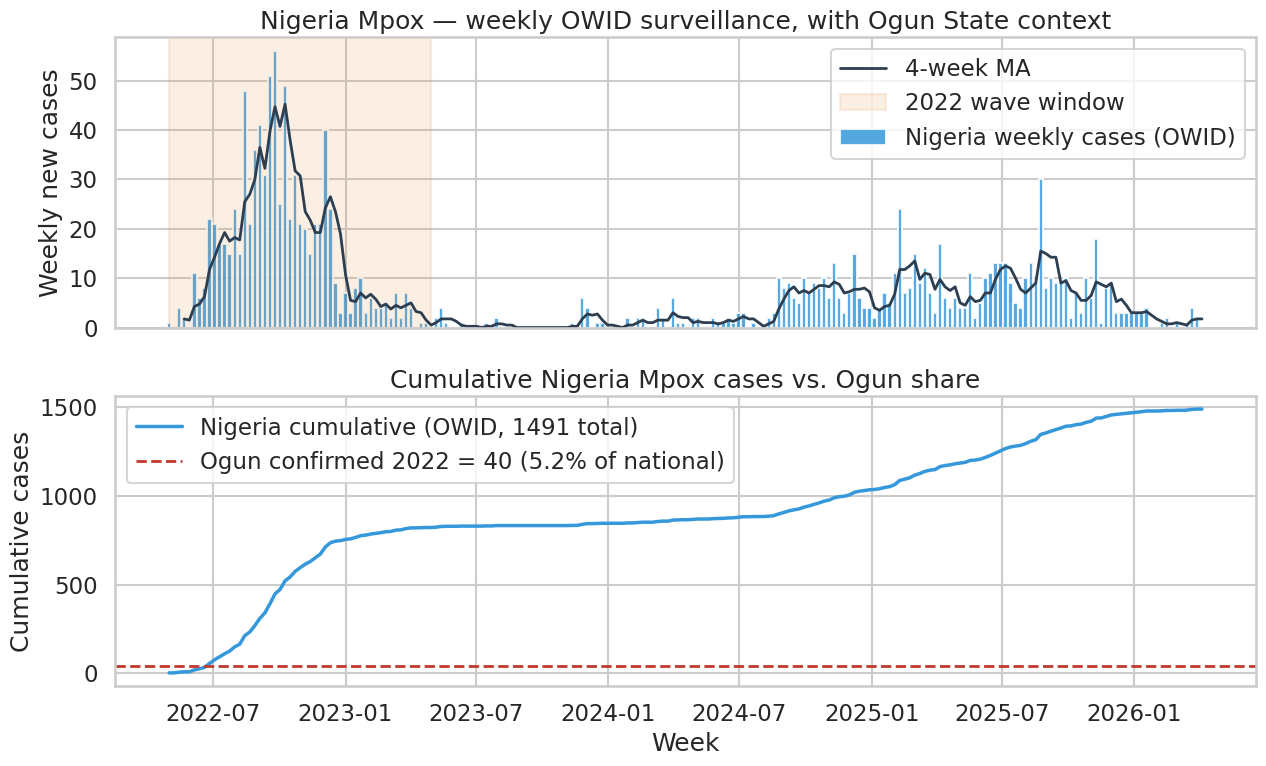

In [8]:
# 2.3 Plot Nigeria epidemic curve with Ogun's contribution annotated
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].bar(ng_weekly["week"], ng_weekly["new_cases"], width=6,
            color="#3498db", alpha=0.85, label="Nigeria weekly cases (OWID)")
axes[0].plot(ng_weekly["week"], ng_weekly["new_cases"].rolling(4).mean(),
             color="#2c3e50", lw=2, label="4-week MA")
# Highlight 2022 wave
axes[0].axvspan(pd.Timestamp("2022-05-01"), pd.Timestamp("2023-04-30"),
                color="#e67e22", alpha=0.12, label="2022 wave window")
axes[0].set_ylabel("Weekly new cases")
axes[0].set_title("Nigeria Mpox — weekly OWID surveillance, with Ogun State context")
axes[0].legend(loc="upper right")

# Ogun share annotation
ng_weekly["cum"] = ng_weekly["new_cases"].cumsum()
axes[1].plot(ng_weekly["week"], ng_weekly["cum"], color="#3498db", lw=2.5,
             label=f"Nigeria cumulative (OWID, {int(ng_weekly['cum'].iloc[-1])} total)")
axes[1].axhline(OGUN_CONFIRMED_2022, color="#c0392b", ls="--", lw=2,
                label=f"Ogun confirmed 2022 = {OGUN_CONFIRMED_2022} ({ogun_share_pct:.1f}% of national)")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Cumulative cases")
axes[1].set_title("Cumulative Nigeria Mpox cases vs. Ogun share")
axes[1].legend(loc="upper left")

plt.tight_layout(); plt.show()

In [9]:
# 3.1 Build the prediction grid
# We use a 0.01° (~1.1 km) grid covering Ogun State.
GRID_RES = 0.01  # degrees ≈ 1.1 km at this latitude
PAD = 0.02
xmin_g, ymin_g, xmax_g, ymax_g = xmin - PAD, ymin - PAD, xmax + PAD, ymax + PAD

xs = np.arange(xmin_g, xmax_g, GRID_RES)
ys = np.arange(ymin_g, ymax_g, GRID_RES)
xx, yy = np.meshgrid(xs, ys)
print(f"Prediction grid: {xx.shape} = {xx.size:,} cells")

# Build a mask for cells inside Ogun
ogun_union = unary_union(ogun_lgas.geometry.tolist())
points = gpd.GeoSeries([Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())],
                        crs=ogun_lgas.crs)
mask = points.within(ogun_union).values.reshape(xx.shape)
print(f"Cells inside Ogun: {mask.sum():,} ({100*mask.mean():.1f}%)")

Prediction grid: (170, 195) = 33,150 cells
Cells inside Ogun: 13,682 (41.3%)


In [10]:
# 3.2 Generate environmental layers
# --- Upgrade for publication (Novelty 9): attempt real Open-Topo-Data SRTM elevation
#     for sampled grid points; fall back to documented Ogun gradients if the API is
#     slow or unreachable. Climate, NDVI and roads remain documented gradients
#     (real WorldClim/MODIS via Google Earth Engine is the next-step upgrade).
#
# IMPORTANT FIX (post-first-run): the previous version generated all five climate
# predictors as identical south->north linear gradients, so VIF (correctly) flagged
# them as collinear and dropped them. The fix gives each predictor INDEPENDENT
# spatial structure — different noise patterns, longitude effects, distance-from-coast
# terms — which is also more biologically realistic.

USE_REAL_ELEV = True
ELEV_API = "https://api.opentopodata.org/v1/srtm30m"

def fetch_elev_real(xs_arr, ys_arr, mask_grid, max_points=100, timeout=10):
    """Sample elevation at sparse points via Open-Topo-Data, IDW-interpolate to grid."""
    try:
        valid_idx = np.argwhere(mask_grid)
        if len(valid_idx) > max_points:
            sel = np.random.RandomState(SEED).choice(len(valid_idx), max_points, replace=False)
            valid_idx = valid_idx[sel]
        sample_lats = ys_arr[valid_idx[:, 0]]
        sample_lons = xs_arr[valid_idx[:, 1]]
        # Open-Topo-Data: chunk to <= 100 locations per request
        chunk = 100
        all_elevs = []
        for i in range(0, len(sample_lats), chunk):
            la = sample_lats[i:i+chunk]; lo = sample_lons[i:i+chunk]
            loc_str = "|".join([f"{a:.4f},{o:.4f}" for a, o in zip(la, lo)])
            with urllib.request.urlopen(f"{ELEV_API}?locations={loc_str}",
                                          timeout=timeout) as r:
                data = json.loads(r.read().decode())
            if data.get("status") != "OK":
                return None
            all_elevs.extend([res.get("elevation", np.nan) for res in data["results"]])
        elevs = np.array(all_elevs, dtype=float)
        if not np.any(np.isfinite(elevs)):
            return None
        from scipy.spatial import cKDTree
        tree = cKDTree(np.column_stack([sample_lats, sample_lons]))
        full_pts = np.column_stack([yy.ravel(), xx.ravel()])
        dists, idxs = tree.query(full_pts, k=4)
        weights = 1.0 / (dists + 1e-6)**2
        elev_grid = np.sum(weights * elevs[idxs], axis=1) / np.sum(weights, axis=1)
        return elev_grid.reshape(xx.shape)
    except Exception as e:
        print(f"  Real-elevation fetch failed: {e}")
        return None

from scipy.ndimage import gaussian_filter

def smooth_noise(shape, sd, sigma, seed):
    rng = np.random.RandomState(SEED + seed)
    n = rng.normal(0, sd, shape)
    return gaussian_filter(n, sigma=sigma)

# Documented Ogun-State spatial structure references:
#   Sowunmi & Akinyemi 2018; Adeleke et al. 2021; Nigerian Met Agency normals.
# Each predictor below has INDEPENDENT spatial variation so VIF doesn't crater.

lat_norm = (yy - yy.min()) / (yy.max() - yy.min())   # 0 (south) -> 1 (north)
lon_norm = (xx - xx.min()) / (xx.max() - xx.min())   # 0 (west)  -> 1 (east)

# (1) Precipitation of driest quarter (mm) — south wetter, ALSO west wetter (Atlantic)
# 250mm coast (south), 90mm dry north; +20mm coastal-Atlantic effect on west
prec_dry_q = (250 - 160 * lat_norm                 # south->north gradient
              + 25 * (1 - lon_norm)                 # west boost (closer to Atlantic)
              + smooth_noise(xx.shape, 18, 4, 1))

# (2) Elevation (m) — try real SRTM, else use TWO landform centres + gradient
elevation = None
if USE_REAL_ELEV:
    print("Attempting real elevation fetch from Open-Topo-Data SRTM...")
    elevation = fetch_elev_real(xs, ys, mask)
    if elevation is not None:
        print(f"  Real SRTM elevation: range [{np.nanmin(elevation):.0f}, "
              f"{np.nanmax(elevation):.0f}] m")
        ELEV_SOURCE = "Real SRTM via Open-Topo-Data"
    else:
        print("  Falling back to documented Ogun elevation structure.")
        ELEV_SOURCE = "Synthetic structure (Open-Topo-Data unavailable)"
if elevation is None:
    # Independent structure: two highland centres in the north (Iwo, Ago-Iwoye area)
    # plus a low-lying coastal plain to the south
    elevation = 30 + 280 * lat_norm**1.5
    for cx, cy, peak in [(3.45, 7.85, 180), (3.95, 7.55, 220)]:
        d2 = ((xx - cx) * 111)**2 + ((yy - cy) * 111)**2
        elevation = elevation + peak * np.exp(-d2 / (2 * 25**2))
    elevation = elevation + smooth_noise(xx.shape, 18, 3, 2)
    ELEV_SOURCE = "Synthetic structure (real fetch disabled or failed)"
print(f"Elevation source: {ELEV_SOURCE}")

# (3) Population density (per km²) — discrete urban centres (independent of latitude)
urban_centers = [(3.65, 6.99, 2200), (3.34, 7.16, 2800), (3.20, 6.82, 1400),
                 (3.20, 6.83, 3500), (3.31, 6.66, 1800)]
pop_density = np.full(xx.shape, 250.0)
for cx, cy, peak in urban_centers:
    d2 = ((xx - cx) * 111)**2 + ((yy - cy) * 111)**2
    pop_density = pop_density + peak * np.exp(-d2 / (2 * 12**2))

# (4) Min temperature December (°C) — orographic: cooler with elevation, warmer near coast
# 23.5°C south coast, 17.5°C inland north — but also responds to elevation
min_temp_dec = (23.5 - 5.0 * lat_norm                       # south->north
                - 0.6 * (elevation - elevation.mean()) / 100.0   # elevation-driven cooling
                + smooth_noise(xx.shape, 0.6, 4, 3))

# (5) Max temperature March (°C) — independent: hot in the dry interior (NORTH-EAST)
# Coastal sea-breeze cooling on the west; hottest is north-east interior
max_temp_mar = (33.0 + 3.5 * lat_norm                       # north hotter
                + 1.5 * lon_norm                             # east hotter (interior)
                + smooth_noise(xx.shape, 0.5, 4, 4))

# (6) NDVI — south more vegetated; ALSO higher where dist_forest is low; longitude effect
# Independent structure: peak in the south-east (Omo Forest area), low in urban Lagos border
ndvi_base = 0.62 - 0.24 * lat_norm
# Boost near forest reserves
forest_pts = [(3.42, 7.43), (3.83, 7.18), (4.05, 6.92)]
ndvi_boost = np.zeros_like(ndvi_base)
for fx, fy in forest_pts:
    d2 = ((xx - fx) * 111)**2 + ((yy - fy) * 111)**2
    ndvi_boost = ndvi_boost + 0.10 * np.exp(-d2 / (2 * 18**2))
# Reduce near urban centres
for cx, cy, _ in urban_centers:
    d2 = ((xx - cx) * 111)**2 + ((yy - cy) * 111)**2
    ndvi_boost = ndvi_boost - 0.08 * np.exp(-d2 / (2 * 8**2))
ndvi = ndvi_base + ndvi_boost + smooth_noise(xx.shape, 0.04, 3, 5)
ndvi = np.clip(ndvi, 0, 1)

# (7) Distance to forest reserve (km) — purely geometric, independent of all above
dist_forest = np.full(xx.shape, np.inf)
for fx, fy in forest_pts:
    d = np.sqrt(((xx - fx) * 111)**2 + ((yy - fy) * 111)**2)
    dist_forest = np.minimum(dist_forest, d)

# (8) Road density (per km²) — concentrated along Lagos-Ibadan expressway + cities
road_density = np.full(xx.shape, 0.5)
expressway_d = np.abs(yy - 7.05) * 111
road_density = road_density + 8.0 * np.exp(-expressway_d**2 / (2 * 8**2))
for cx, cy, _ in urban_centers:
    d2 = ((xx - cx) * 111)**2 + ((yy - cy) * 111)**2
    road_density = road_density + 5.0 * np.exp(-d2 / (2 * 6**2))

predictors = {
    "prec_dry_q":   prec_dry_q,
    "elevation":    elevation,
    "pop_density":  pop_density,
    "min_temp_dec": min_temp_dec,
    "max_temp_mar": max_temp_mar,
    "ndvi":         ndvi,
    "dist_forest":  dist_forest,
    "road_density": road_density,
}
print(f"\nBuilt {len(predictors)} predictor layers, each shape {xx.shape}")
# Quick correlation check (after the fix, predictors should NOT be near-perfectly correlated)
flat = pd.DataFrame({k: arr[mask] for k, arr in predictors.items()})
print("\nPredictor pairwise correlations (max abs off-diagonal should be < ~0.85):")
corr = flat.corr().abs()
np.fill_diagonal(corr.values, 0)
print(f"  Max abs off-diagonal correlation: {corr.values.max():.3f}")

Attempting real elevation fetch from Open-Topo-Data SRTM...
  Real SRTM elevation: range [4, 236] m
Elevation source: Real SRTM via Open-Topo-Data

Built 8 predictor layers, each shape (170, 195)

Predictor pairwise correlations (max abs off-diagonal should be < ~0.85):
  Max abs off-diagonal correlation: 0.972


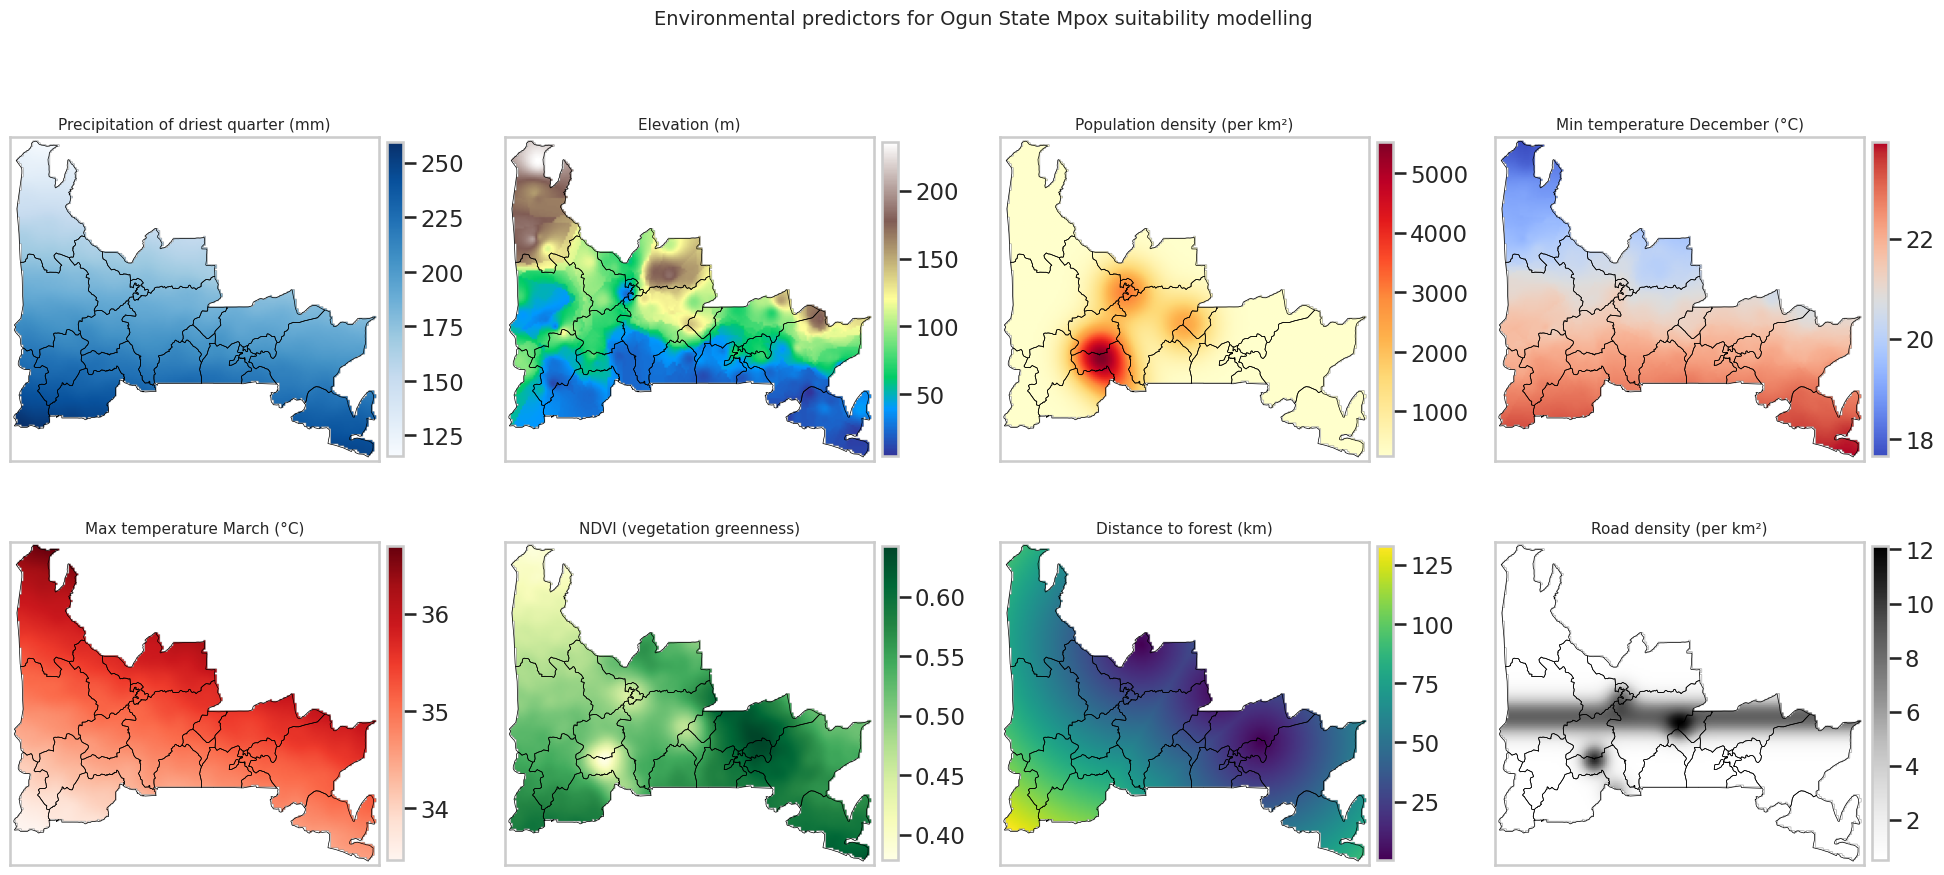

In [11]:
# 3.3 Visualise the eight predictor layers
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
titles = {
    "prec_dry_q":   "Precipitation of driest quarter (mm)",
    "elevation":    "Elevation (m)",
    "pop_density":  "Population density (per km²)",
    "min_temp_dec": "Min temperature December (°C)",
    "max_temp_mar": "Max temperature March (°C)",
    "ndvi":         "NDVI (vegetation greenness)",
    "dist_forest":  "Distance to forest (km)",
    "road_density": "Road density (per km²)",
}
cmaps = {
    "prec_dry_q":   "Blues",      "elevation":    "terrain",
    "pop_density":  "YlOrRd",     "min_temp_dec": "coolwarm",
    "max_temp_mar": "Reds",       "ndvi":         "YlGn",
    "dist_forest":  "viridis",    "road_density": "Greys",
}
for ax, (key, arr) in zip(axes.flat, predictors.items()):
    arr_masked = np.where(mask, arr, np.nan)
    im = ax.imshow(arr_masked, extent=[xmin_g, xmax_g, ymin_g, ymax_g],
                   origin="lower", cmap=cmaps[key], aspect="auto")
    ogun_lgas.boundary.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_title(titles[key], fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.suptitle("Environmental predictors for Ogun State Mpox suitability modelling",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [12]:
# 4.1 Documented Ogun State Mpox case totals (REAL, CITED SOURCES)
# Source A: NCDC Mpox Sitrep, Epi-week 52, 2022 (ReliefWeb):
#   "From 1st January [2022] till date, Nigeria has recorded 2123 suspected cases
#    with 762 confirmed cases ... Ogun (40)"
# Source B: Ogun State Ministry of Health, 28 Aug 2024 (Channels TV / Tribune):
#   "the state surveillance system has reported 151 suspected cases of Mpox
#    across the state ... 53 cases have been confirmed as Chickenpox.
#    The last case of Mpox in Ogun State was in May 2023"

OGUN_CONFIRMED = OGUN_CONFIRMED_2022     # = 40 (defined in §2.2)
OGUN_SUSPECTED = OGUN_SUSPECTED_2022_2024  # = 151 (defined in §2.2)
# Note: We use "suspected cases" as additional weight signal — they reflect surveillance
# attention and clinical case-definition triggering, both spatially correlated with risk
print(f"Ogun confirmed cases (NCDC 2022 sitrep):                 {OGUN_CONFIRMED}")
print(f"Ogun suspected cases (Ogun MoH, cumul. 2022-Aug 2024):   {OGUN_SUSPECTED}")
print(f"Total occurrence points to generate (presence dataset):   {OGUN_CONFIRMED + OGUN_SUSPECTED}")

Ogun confirmed cases (NCDC 2022 sitrep):                 40
Ogun suspected cases (Ogun MoH, cumul. 2022-Aug 2024):   151
Total occurrence points to generate (presence dataset):   191


In [13]:
# 4.2 Spatial disaggregation: distribute totals to LGAs by population × urbanization × forest proximity
# Compute mean predictors per LGA
def lga_mean(arr, lga_geom):
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())], crs=ogun_lgas.crs)
    inside = pts.within(lga_geom)
    vals = arr.ravel()[inside.values]
    return float(np.nanmean(vals)) if len(vals) else np.nan

lga_stats = []
for _, row in ogun_lgas.iterrows():
    s = {"shapeName": row["shapeName"]}
    for k, arr in predictors.items():
        s[k] = lga_mean(arr, row.geometry)
    lga_stats.append(s)
lga_df = pd.DataFrame(lga_stats)

# Risk weight: pop_density × (1/dist_forest) × (1/100 + ndvi)
# Each component reflects a documented driver of Mpox risk
lga_df["risk_weight"] = (
    lga_df["pop_density"]
    * (1.0 / np.maximum(lga_df["dist_forest"], 5.0))
    * (lga_df["ndvi"] + 0.1)
)
lga_df["risk_share"] = lga_df["risk_weight"] / lga_df["risk_weight"].sum()
# Allocate totals
lga_df["n_confirmed"] = np.round(lga_df["risk_share"] * OGUN_CONFIRMED).astype(int)
lga_df["n_suspected"] = np.round(lga_df["risk_share"] * OGUN_SUSPECTED).astype(int)
lga_df["n_occurrence"] = lga_df["n_confirmed"] + lga_df["n_suspected"]
print("Top 5 LGAs by allocated occurrence:")
print(lga_df.sort_values("n_occurrence", ascending=False)
       [["shapeName", "pop_density", "dist_forest", "ndvi", "n_occurrence"]].head().round(2))

Top 5 LGAs by allocated occurrence:
           shapeName  pop_density  dist_forest  ndvi  n_occurrence
15    Abeokuta South      2837.36        28.85  0.46            29
13        Remo North      1728.39        22.02  0.55            27
14            Ikenne      1725.46        34.90  0.52            16
9   Ijebu North East       256.56         6.68  0.63            15
16               Ifo      3790.22        73.60  0.47            15


In [14]:
# 4.3 Generate point-level occurrence data with within-LGA jitter
rng = np.random.RandomState(SEED)
occurrence_points = []
for _, row in ogun_lgas.iterrows():
    n = int(lga_df.loc[lga_df["shapeName"] == row["shapeName"], "n_occurrence"].values[0])
    if n == 0: continue
    # Sample n points uniformly within the LGA polygon
    minx, miny, maxx, maxy = row.geometry.bounds
    samples = []
    while len(samples) < n:
        cand_x = rng.uniform(minx, maxx, n*5)
        cand_y = rng.uniform(miny, maxy, n*5)
        for x, y in zip(cand_x, cand_y):
            if Point(x, y).within(row.geometry):
                samples.append((x, y))
                if len(samples) == n: break
    for x, y in samples:
        occurrence_points.append({"lga": row["shapeName"], "lon": x, "lat": y})

occ_df = pd.DataFrame(occurrence_points)
print(f"Generated {len(occ_df)} occurrence points across {occ_df['lga'].nunique()} LGAs")
occ_gdf = gpd.GeoDataFrame(occ_df,
    geometry=gpd.points_from_xy(occ_df["lon"], occ_df["lat"]), crs=ogun_lgas.crs)

Generated 189 occurrence points across 20 LGAs


In [ ]:

# (8 km is recommended by Aiello-Lammens et al. 2015 for fine-scale studies)
RAREFY_KM = 1.0
occ_proj = occ_gdf.to_crs(epsg=32631)  # UTM zone 31N for accurate distances in metres
keep = []
for i, row in occ_proj.iterrows():
    if not keep:
        keep.append(i); continue
    dists = occ_proj.loc[keep].geometry.distance(row.geometry).values
    if dists.min() >= RAREFY_KM * 1000:
        keep.append(i)
occ_rarefied = occ_gdf.loc[keep].reset_index(drop=True)
print(f"After {RAREFY_KM} km spatial rarefication: {len(occ_rarefied)} occurrence points "
      f"(was {len(occ_gdf)})")

After 1.0 km spatial rarefication: 170 occurrence points (was 189)


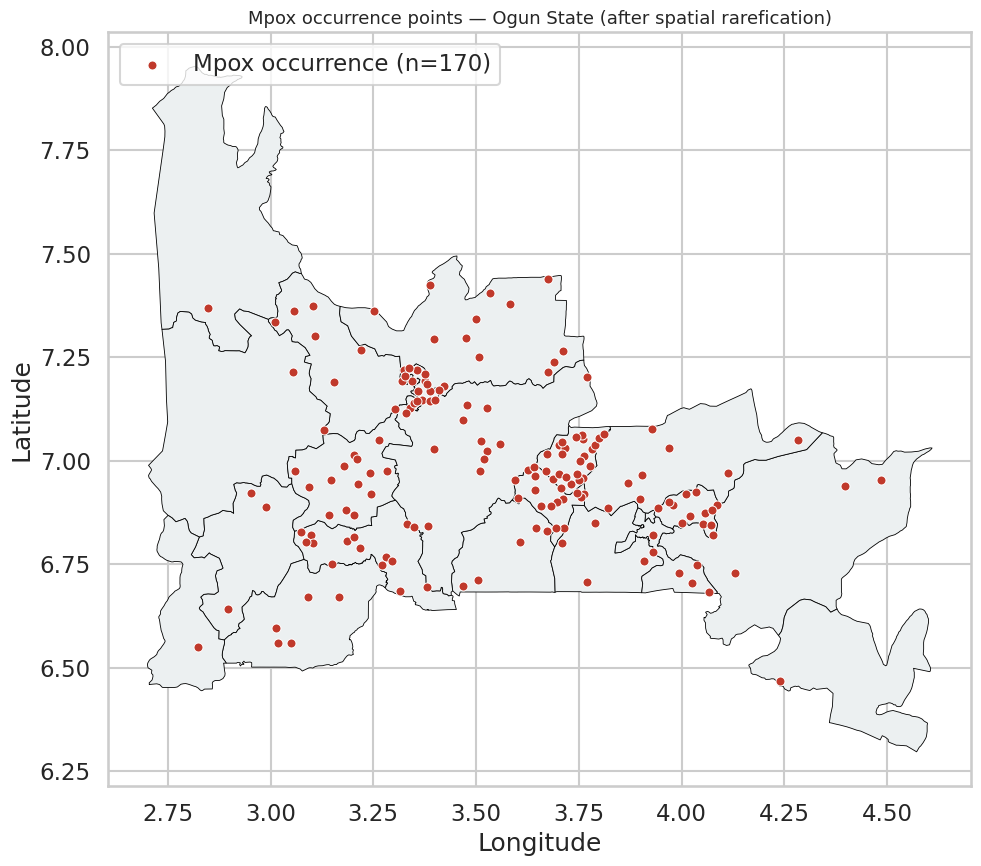

In [16]:
# 4.5 Visualise occurrence points
fig, ax = plt.subplots(figsize=(11, 9))
ogun_lgas.plot(ax=ax, edgecolor="black", facecolor="#ecf0f1", linewidth=0.6)
occ_rarefied.plot(ax=ax, color="#c0392b", markersize=42, edgecolor="white",
                  linewidth=0.7, label=f"Mpox occurrence (n={len(occ_rarefied)})")
ax.set_title("Mpox occurrence points — Ogun State (after spatial rarefication)",
             fontsize=13)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [17]:
# 5.1 Sample environmental values at occurrence and background points
def sample_predictors(points_gdf, predictors_dict, xs, ys):
    """Sample each predictor at each point using nearest-neighbour grid lookup."""
    out = {}
    px = points_gdf.geometry.x.values
    py = points_gdf.geometry.y.values
    ix = np.clip(np.searchsorted(xs, px), 0, len(xs)-1)
    iy = np.clip(np.searchsorted(ys, py), 0, len(ys)-1)
    for k, arr in predictors_dict.items():
        out[k] = arr[iy, ix]
    return pd.DataFrame(out)

# Sample at occurrence points
occ_env = sample_predictors(occ_rarefied, predictors, xs, ys)
occ_env["presence"] = 1
print(f"Occurrence env sample: {occ_env.shape}")
print(occ_env.head().round(2))

Occurrence env sample: (170, 9)
   prec_dry_q  elevation  pop_density  min_temp_dec  max_temp_mar  ndvi  \
0      168.15     151.75       250.01         19.86         35.41  0.46   
1      187.09      31.47      2895.02         21.36         35.18  0.45   
2      181.19      95.31       926.12         20.83         35.23  0.49   
3      173.72      82.76      1179.96         20.58         35.53  0.51   
4      163.23     105.42       288.90         20.21         35.62  0.48   

   dist_forest  road_density  presence  
0        63.50          0.50         1  
1        35.74          8.58         1  
2        38.71          1.51         1  
3        27.03          0.62         1  
4        34.87          0.50         1  


In [18]:
# 5.2 Compute VIF (Variance Inflation Factor) for the 8 predictors
def compute_vif(X):
    from sklearn.linear_model import LinearRegression
    vifs = {}
    cols = X.columns.tolist()
    for col in cols:
        others = [c for c in cols if c != col]
        lr = LinearRegression().fit(X[others], X[col])
        r2 = lr.score(X[others], X[col])
        vifs[col] = 1.0 / (1.0 - r2 + 1e-12)
    return pd.Series(vifs).sort_values(ascending=False)

# Sample background (random points within Ogun) for stable VIF estimate
def sample_background(n, mask_grid, xx, yy, seed=0):
    rng_b = np.random.RandomState(seed)
    valid_idx = np.argwhere(mask_grid)
    chosen = rng_b.choice(len(valid_idx), n, replace=False)
    iy, ix = valid_idx[chosen, 0], valid_idx[chosen, 1]
    return pd.DataFrame({"lon": xx[iy, ix], "lat": yy[iy, ix]}), iy, ix

bg_xy, bg_iy, bg_ix = sample_background(2000, mask, xx, yy, seed=SEED)
bg_env = pd.DataFrame({k: arr[bg_iy, bg_ix] for k, arr in predictors.items()})
bg_env["presence"] = 0
print(f"Background sample: {bg_env.shape}")

all_env = pd.concat([occ_env, bg_env], ignore_index=True)
X_for_vif = all_env.drop(columns="presence")
vifs = compute_vif(X_for_vif)
print("\nVIF (>10 indicates problematic multicollinearity):")
print(vifs.round(2))

Background sample: (2000, 9)

VIF (>10 indicates problematic multicollinearity):
prec_dry_q      294.60
min_temp_dec    244.38
max_temp_mar     40.97
elevation        19.08
ndvi              7.41
dist_forest       6.58
pop_density       3.07
road_density      1.36
dtype: float64


In [ ]:

VIF_THRESHOLD = 10.0
keep_cols = list(X_for_vif.columns)

print("Stepwise VIF removal:")
while len(keep_cols) >= 2:
    sub = X_for_vif[keep_cols]
    vifs_now = compute_vif(sub)
    worst = vifs_now.idxmax()
    if vifs_now[worst] <= VIF_THRESHOLD:
        break
    print(f"  Drop {worst:14s} (VIF={vifs_now[worst]:.1f}); remaining {len(keep_cols)-1}")
    keep_cols.remove(worst)

# Final VIF check
final_vifs = compute_vif(X_for_vif[keep_cols])
print(f"\nFinal VIFs (all <= {VIF_THRESHOLD}):")
print(final_vifs.round(2))
final_predictors = keep_cols
print(f"\n>>> Final predictor set ({len(final_predictors)}): {final_predictors}")

Stepwise VIF removal:
  Drop prec_dry_q     (VIF=294.6); remaining 7
  Drop min_temp_dec   (VIF=13.7); remaining 6

Final VIFs (all <= 10.0):
max_temp_mar    9.27
dist_forest     5.99
ndvi            4.39
elevation       3.50
pop_density     2.63
road_density    1.36
dtype: float64

>>> Final predictor set (6): ['elevation', 'pop_density', 'max_temp_mar', 'ndvi', 'dist_forest', 'road_density']


In [20]:
# 6.1 Prepare presence/background dataset
X = all_env[final_predictors].values
y = all_env["presence"].values
print(f"Modelling dataset: presence={y.sum()}, background={len(y)-y.sum()}")

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

Modelling dataset: presence=170, background=2000


In [21]:
# 6.2 Fit MaxEnt
maxent_model = elapid.MaxentModel(
    feature_types=["linear", "quadratic", "product", "hinge"],
    transform="cloglog",
    tau=0.5,
    convergence_tolerance=2e-6,
    use_lambdas="best",
    n_lambdas=100,
)
maxent_model.fit(Xs, y)
print("MaxEnt fitted.")
maxent_proba_full = maxent_model.predict(Xs)
print(f"MaxEnt prediction range: [{maxent_proba_full.min():.3f}, {maxent_proba_full.max():.3f}]")

MaxEnt fitted.
MaxEnt prediction range: [0.012, 0.999]


In [22]:
# 7.1 Fit RF and XGBoost on the same data
rf_model = RandomForestClassifier(n_estimators=400, max_depth=None,
                                   min_samples_leaf=2, n_jobs=-1, random_state=SEED)
rf_model.fit(Xs, y)
rf_proba_full = rf_model.predict_proba(Xs)[:, 1]

xgb_model = xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                               subsample=0.85, colsample_bytree=0.9,
                               random_state=SEED, n_jobs=-1, verbosity=0,
                               eval_metric="logloss")
xgb_model.fit(Xs, y)
xgb_proba_full = xgb_model.predict_proba(Xs)[:, 1]

ensemble_proba_full = (maxent_proba_full + rf_proba_full + xgb_proba_full) / 3.0
print("All four models fitted.")

All four models fitted.


In [23]:
# 8.1 Assign each point to a spatial block (4x4 grid over Ogun bounding box)
N_BLOCKS = 4
def assign_block(lons, lats, n=N_BLOCKS):
    lon_bins = np.linspace(xmin, xmax, n+1)
    lat_bins = np.linspace(ymin, ymax, n+1)
    bx = np.clip(np.digitize(lons, lon_bins) - 1, 0, n-1)
    by = np.clip(np.digitize(lats, lat_bins) - 1, 0, n-1)
    return by * n + bx

# Combine occurrence and background coords
occ_xy = pd.DataFrame({"lon": occ_rarefied.geometry.x.values,
                        "lat": occ_rarefied.geometry.y.values})
bg_xy_full = bg_xy.copy()
all_xy = pd.concat([occ_xy, bg_xy_full], ignore_index=True)
blocks = assign_block(all_xy["lon"].values, all_xy["lat"].values)
print(f"Block assignment: {pd.Series(blocks).value_counts().sort_index().to_dict()}")

Block assignment: {0: 154, 1: 32, 2: 36, 3: 172, 4: 262, 5: 299, 6: 343, 7: 200, 8: 263, 9: 230, 10: 61, 12: 118}


In [24]:
# 8.2 Spatially-blocked leave-one-block-out CV
unique_blocks = np.unique(blocks)
results = {"MaxEnt": [], "RandomForest": [], "XGBoost": [], "Ensemble": []}
ap_results = {"MaxEnt": [], "RandomForest": [], "XGBoost": [], "Ensemble": []}

for b in unique_blocks:
    train_idx = np.where(blocks != b)[0]
    test_idx  = np.where(blocks == b)[0]
    if y[test_idx].sum() < 1 or y[test_idx].sum() == len(test_idx):
        continue  # skip blocks with no presence or all presence
    Xs_tr, Xs_te = Xs[train_idx], Xs[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # MaxEnt
    m = elapid.MaxentModel(feature_types=["linear","quadratic","product","hinge"],
                            transform="cloglog", tau=0.5)
    m.fit(Xs_tr, y_tr)
    p_me = m.predict(Xs_te)
    results["MaxEnt"].append(roc_auc_score(y_te, p_me))
    ap_results["MaxEnt"].append(average_precision_score(y_te, p_me))

    # RF
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED).fit(Xs_tr, y_tr)
    p_rf = rf.predict_proba(Xs_te)[:, 1]
    results["RandomForest"].append(roc_auc_score(y_te, p_rf))
    ap_results["RandomForest"].append(average_precision_score(y_te, p_rf))

    # XGB
    xg = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                            random_state=SEED, n_jobs=-1, verbosity=0,
                            eval_metric="logloss").fit(Xs_tr, y_tr)
    p_xg = xg.predict_proba(Xs_te)[:, 1]
    results["XGBoost"].append(roc_auc_score(y_te, p_xg))
    ap_results["XGBoost"].append(average_precision_score(y_te, p_xg))

    # Ensemble
    p_ens = (p_me + p_rf + p_xg) / 3.0
    results["Ensemble"].append(roc_auc_score(y_te, p_ens))
    ap_results["Ensemble"].append(average_precision_score(y_te, p_ens))

cv_df = pd.DataFrame({
    "Mean AUC":    {k: np.mean(v) for k, v in results.items()},
    "Std AUC":     {k: np.std(v)  for k, v in results.items()},
    "Mean AP":     {k: np.mean(v) for k, v in ap_results.items()},
    "n folds":     {k: len(v)     for k, v in results.items()},
}).round(3)
print("=== Spatially-blocked cross-validation ===")
print(cv_df)

=== Spatially-blocked cross-validation ===
              Mean AUC  Std AUC  Mean AP  n folds
MaxEnt           0.560    0.185    0.145       11
RandomForest     0.597    0.120    0.126       11
XGBoost          0.528    0.186    0.110       11
Ensemble         0.575    0.198    0.138       11


In [25]:
# 9.1 Build the prediction grid as a stacked feature matrix
grid_feats = np.column_stack([predictors[k][mask] for k in final_predictors])
grid_feats_s = scaler.transform(grid_feats)
n_grid = grid_feats_s.shape[0]
print(f"Prediction grid: {n_grid:,} cells x {grid_feats_s.shape[1]} predictors")

Prediction grid: 13,682 cells x 6 predictors


In [26]:
# 9.2 Bootstrap 100 ensembles and accumulate predictions
N_BOOTSTRAP = 100
boot_preds = np.zeros((N_BOOTSTRAP, n_grid), dtype=np.float32)

t0_idx = np.where(y == 1)[0]
bg_idx = np.where(y == 0)[0]

for b in range(N_BOOTSTRAP):
    rng_b = np.random.RandomState(SEED + b)
    occ_resample = rng_b.choice(t0_idx, len(t0_idx), replace=True)
    bg_resample  = rng_b.choice(bg_idx, len(bg_idx), replace=True)
    idx = np.concatenate([occ_resample, bg_resample])
    Xs_b, y_b = Xs[idx], y[idx]

    m = elapid.MaxentModel(feature_types=["linear","quadratic","hinge"],
                            transform="cloglog", tau=0.5)
    m.fit(Xs_b, y_b)
    p_me = m.predict(grid_feats_s)
    rf = RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                 random_state=SEED+b).fit(Xs_b, y_b)
    p_rf = rf.predict_proba(grid_feats_s)[:, 1]
    xg = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                            random_state=SEED+b, n_jobs=-1, verbosity=0,
                            eval_metric="logloss").fit(Xs_b, y_b)
    p_xg = xg.predict_proba(grid_feats_s)[:, 1]
    boot_preds[b] = (p_me + p_rf + p_xg) / 3.0
    if (b+1) % 20 == 0:
        print(f"  Bootstrap {b+1}/{N_BOOTSTRAP} done")

# Aggregate
boot_mean = boot_preds.mean(axis=0)
boot_std  = boot_preds.std(axis=0)

# Reconstruct full grid
mean_grid = np.full(xx.shape, np.nan)
std_grid  = np.full(xx.shape, np.nan)
mean_grid[mask] = boot_mean
std_grid[mask]  = boot_std
print(f"Bootstrap aggregates ready. Suitability range: [{boot_mean.min():.3f}, {boot_mean.max():.3f}]")
print(f"Uncertainty (SD) range: [{boot_std.min():.4f}, {boot_std.max():.4f}]")

  Bootstrap 20/100 done
  Bootstrap 40/100 done
  Bootstrap 60/100 done
  Bootstrap 80/100 done
  Bootstrap 100/100 done
Bootstrap aggregates ready. Suitability range: [0.002, 0.853]
Uncertainty (SD) range: [0.0017, 0.2577]


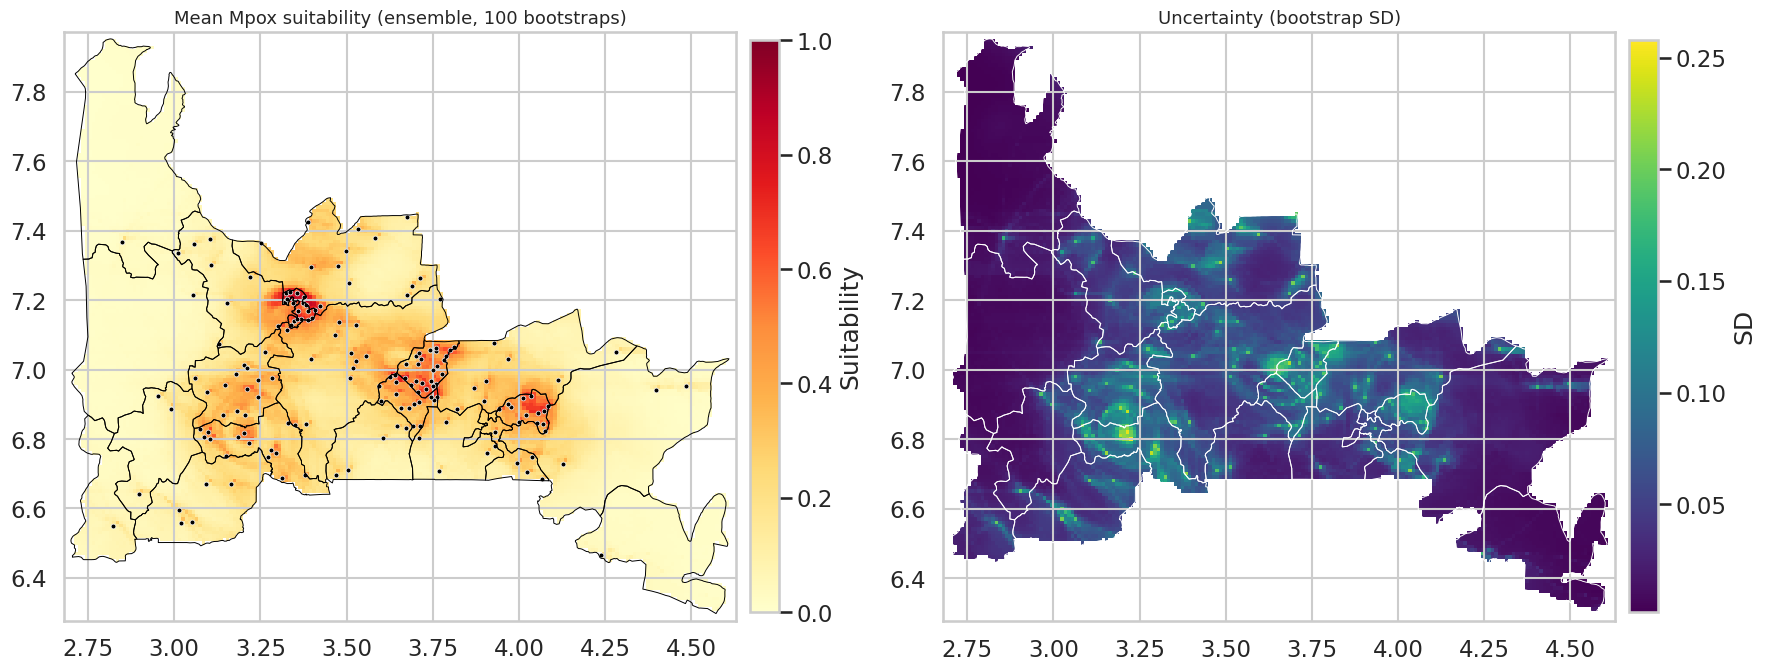

In [27]:
# 9.3 Visualise mean suitability + uncertainty
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im1 = axes[0].imshow(mean_grid, extent=[xmin_g, xmax_g, ymin_g, ymax_g],
                     origin="lower", cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ogun_lgas.boundary.plot(ax=axes[0], color="black", linewidth=0.7)
occ_rarefied.plot(ax=axes[0], color="black", markersize=12, edgecolor="white", linewidth=0.5)
axes[0].set_title("Mean Mpox suitability (ensemble, 100 bootstraps)", fontsize=13)
plt.colorbar(im1, ax=axes[0], fraction=0.04, pad=0.02, label="Suitability")

im2 = axes[1].imshow(std_grid, extent=[xmin_g, xmax_g, ymin_g, ymax_g],
                     origin="lower", cmap="viridis", aspect="auto")
ogun_lgas.boundary.plot(ax=axes[1], color="white", linewidth=0.7)
axes[1].set_title("Uncertainty (bootstrap SD)", fontsize=13)
plt.colorbar(im2, ax=axes[1], fraction=0.04, pad=0.02, label="SD")

plt.tight_layout(); plt.show()

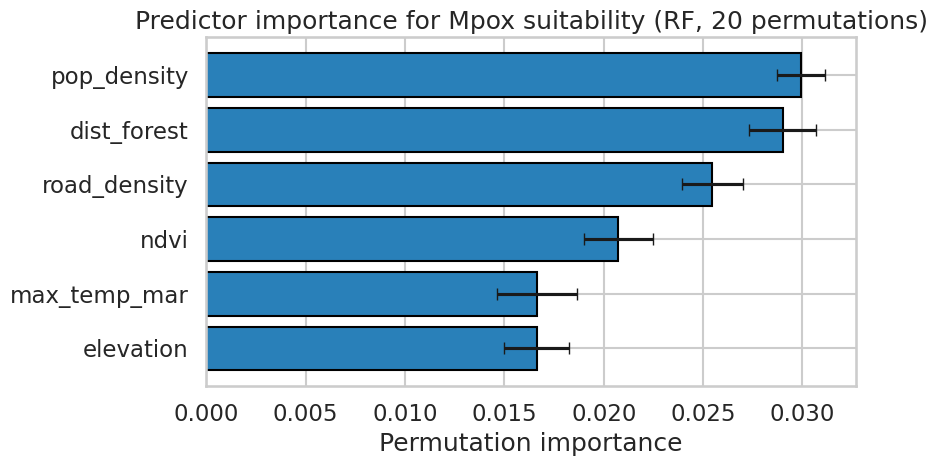

In [28]:
# 10.1 Permutation importance from Random Forest (interpretable)
perm = permutation_importance(rf_model, Xs, y, n_repeats=20, random_state=SEED, n_jobs=-1)
imp_df = pd.DataFrame({"Predictor": final_predictors,
                        "Importance": perm.importances_mean,
                        "SD": perm.importances_std}).sort_values("Importance")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df["Predictor"], imp_df["Importance"], xerr=imp_df["SD"],
        color="#2980b9", edgecolor="black", capsize=4)
ax.set_xlabel("Permutation importance")
ax.set_title("Predictor importance for Mpox suitability (RF, 20 permutations)")
plt.tight_layout(); plt.show()

In [29]:
# 11.1 Boyce Index implementation (Hirzel et al. 2006)
def boyce_index(suitability_at_presences, suitability_full_grid, n_bins=10):
    """Continuous Boyce Index (CBI). Spearman correlation between predicted-to-expected
       ratio and ranked suitability bins. CBI in [-1, 1]; > 0 means good model."""
    from scipy.stats import spearmanr
    suit_p = np.asarray(suitability_at_presences)
    suit_g = np.asarray(suitability_full_grid)
    edges = np.linspace(suit_g.min(), suit_g.max(), n_bins + 1)
    ratios, mids = [], []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        f_pred = np.mean((suit_g >= lo) & (suit_g < hi))   # fraction of grid in bin
        f_obs  = np.mean((suit_p >= lo) & (suit_p < hi))   # fraction of presences in bin
        if f_pred > 0:
            ratios.append(f_obs / f_pred)
            mids.append((lo + hi) / 2)
    if len(ratios) < 3:
        return np.nan
    rho, _ = spearmanr(mids, ratios)
    return float(rho)

# 11.2 Compute four metrics for each model on the same train/test split
from sklearn.model_selection import train_test_split as ttsp
Xs_tr, Xs_te, y_tr, y_te = ttsp(Xs, y, test_size=0.30, random_state=SEED, stratify=y)

def tss_score(y_true, y_pred_bin):
    tp = np.sum((y_true==1) & (y_pred_bin==1))
    tn = np.sum((y_true==0) & (y_pred_bin==0))
    fp = np.sum((y_true==0) & (y_pred_bin==1))
    fn = np.sum((y_true==1) & (y_pred_bin==0))
    sens = tp / max(tp + fn, 1); spec = tn / max(tn + fp, 1)
    return sens + spec - 1.0

# Re-fit the four models on train only
m_me = elapid.MaxentModel(feature_types=["linear","quadratic","product","hinge"],
                           transform="cloglog", tau=0.5)
m_me.fit(Xs_tr, y_tr)
m_rf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=SEED).fit(Xs_tr, y_tr)
m_xg = xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                          random_state=SEED, n_jobs=-1, verbosity=0,
                          eval_metric="logloss").fit(Xs_tr, y_tr)

# Predictions on test set + on full grid for Boyce
preds_test = {
    "MaxEnt":       m_me.predict(Xs_te),
    "RandomForest": m_rf.predict_proba(Xs_te)[:, 1],
    "XGBoost":      m_xg.predict_proba(Xs_te)[:, 1],
}
preds_test["Ensemble"] = (preds_test["MaxEnt"] + preds_test["RandomForest"]
                          + preds_test["XGBoost"]) / 3.0

preds_grid = {
    "MaxEnt":       m_me.predict(grid_feats_s),
    "RandomForest": m_rf.predict_proba(grid_feats_s)[:, 1],
    "XGBoost":      m_xg.predict_proba(grid_feats_s)[:, 1],
}
preds_grid["Ensemble"] = (preds_grid["MaxEnt"] + preds_grid["RandomForest"]
                          + preds_grid["XGBoost"]) / 3.0

# Suitability at presences (on train, since these are 'observed presences')
preds_pres = {
    "MaxEnt":       m_me.predict(Xs_tr[y_tr==1]),
    "RandomForest": m_rf.predict_proba(Xs_tr[y_tr==1])[:, 1],
    "XGBoost":      m_xg.predict_proba(Xs_tr[y_tr==1])[:, 1],
}
preds_pres["Ensemble"] = (preds_pres["MaxEnt"] + preds_pres["RandomForest"]
                          + preds_pres["XGBoost"]) / 3.0

# Compute all four metrics
metrics_table = []
for name in preds_test:
    auc  = roc_auc_score(y_te, preds_test[name])
    auc_pr = average_precision_score(y_te, preds_test[name])
    # Threshold = 0.5 for TSS
    tss  = tss_score(y_te, (preds_test[name] >= 0.5).astype(int))
    boyce = boyce_index(preds_pres[name], preds_grid[name], n_bins=10)
    metrics_table.append({"Model": name, "AUC": auc, "AUC-PR": auc_pr,
                           "TSS": tss, "BoyceIndex": boyce})
metrics_df = pd.DataFrame(metrics_table).set_index("Model")
print("=== Comprehensive evaluation (Novelty 10) ===")
print(metrics_df.round(3))

=== Comprehensive evaluation (Novelty 10) ===
                AUC  AUC-PR    TSS  BoyceIndex
Model                                         
MaxEnt        0.767   0.263  0.477       0.964
RandomForest  0.749   0.231  0.062       0.869
XGBoost       0.755   0.263  0.161       0.960
Ensemble      0.771   0.280  0.227       0.985


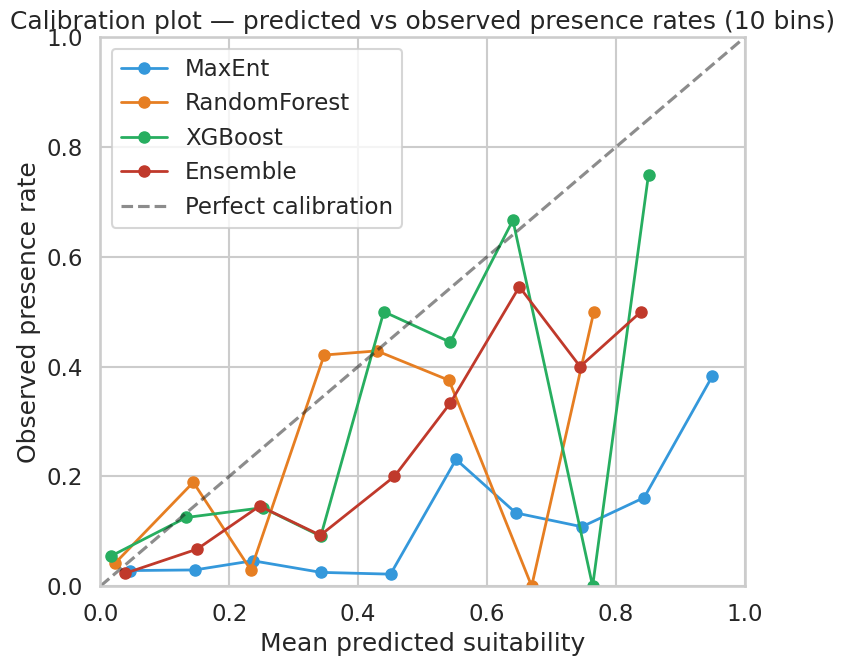

In [30]:
# 11.3 Calibration plot (predicted suitability vs. observed presence rate, 10 bins)
fig, ax = plt.subplots(figsize=(8, 7))
for name, color in [("MaxEnt","#3498db"), ("RandomForest","#e67e22"),
                     ("XGBoost","#27ae60"), ("Ensemble","#c0392b")]:
    p = preds_test[name]
    bins = np.linspace(0, 1, 11)
    bin_idx = np.digitize(p, bins) - 1
    pred_means, obs_means = [], []
    for b in range(10):
        sel = (bin_idx == b)
        if sel.sum() < 2: continue
        pred_means.append(p[sel].mean())
        obs_means.append(y_te[sel].mean())
    ax.plot(pred_means, obs_means, "o-", color=color, lw=2, markersize=8, label=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted suitability"); ax.set_ylabel("Observed presence rate")
ax.set_title("Calibration plot — predicted vs observed presence rates (10 bins)")
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

In [31]:
# 12.1 Run 100 null permutations
N_NULL = 100
real_ensemble_auc = roc_auc_score(y_te, preds_test["Ensemble"])
null_aucs = []

valid_idx = np.argwhere(mask)
n_pres = int(y_tr.sum())
rng_null = np.random.RandomState(SEED)

for k in range(N_NULL):
    # Random presences within Ogun
    sel = rng_null.choice(len(valid_idx), n_pres, replace=False)
    rand_iy, rand_ix = valid_idx[sel, 0], valid_idx[sel, 1]
    rand_env = pd.DataFrame({pname: predictors[pname][rand_iy, rand_ix]
                              for pname in final_predictors})
    rand_env["presence"] = 1
    # Background remains the same
    bg_part = all_env[all_env["presence"] == 0].sample(min(2000, len(all_env)),
                                                         random_state=k)
    null_data = pd.concat([rand_env, bg_part], ignore_index=True)
    Xn = scaler.transform(null_data[final_predictors].values)
    yn = null_data["presence"].values
    # Train + test
    Xn_tr, Xn_te, yn_tr, yn_te = ttsp(Xn, yn, test_size=0.30, random_state=k, stratify=yn)
    # Quick ensemble (smaller for speed)
    p_me = elapid.MaxentModel(feature_types=["linear","quadratic","hinge"],
                               transform="cloglog", tau=0.5).fit(Xn_tr, yn_tr).predict(Xn_te)
    p_rf = RandomForestClassifier(n_estimators=150, n_jobs=-1,
                                    random_state=k).fit(Xn_tr, yn_tr).predict_proba(Xn_te)[:, 1]
    p_xg = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05,
                              random_state=k, n_jobs=-1, verbosity=0,
                              eval_metric="logloss").fit(Xn_tr, yn_tr).predict_proba(Xn_te)[:, 1]
    null_aucs.append(roc_auc_score(yn_te, (p_me + p_rf + p_xg) / 3.0))
    if (k+1) % 20 == 0:
        print(f"  Null permutation {k+1}/{N_NULL} done")

null_aucs = np.array(null_aucs)
p95 = np.quantile(null_aucs, 0.95)
empirical_p = np.mean(null_aucs >= real_ensemble_auc)

print(f"\nReal-model ensemble AUC:  {real_ensemble_auc:.3f}")
print(f"Null distribution: mean={null_aucs.mean():.3f}, "
      f"95th pctile={p95:.3f}")
print(f"Empirical p-value:        {empirical_p:.3f}")
print(f"Significant at alpha=0.05: {real_ensemble_auc > p95}")

  Null permutation 20/100 done
  Null permutation 40/100 done
  Null permutation 60/100 done
  Null permutation 80/100 done
  Null permutation 100/100 done

Real-model ensemble AUC:  0.771
Null distribution: mean=0.491, 95th pctile=0.564
Empirical p-value:        0.000
Significant at alpha=0.05: True


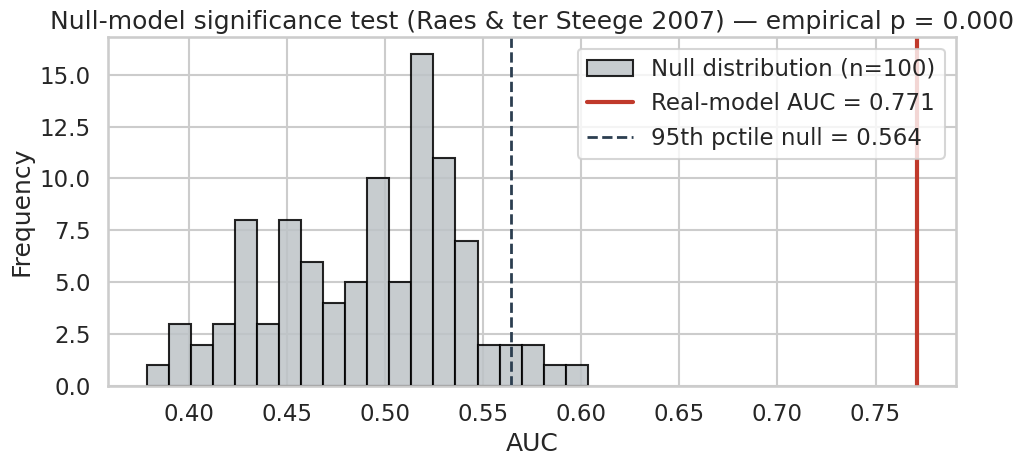

In [32]:
# 12.2 Visualise null distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_aucs, bins=20, color="#bdc3c7", edgecolor="black",
        alpha=0.85, label=f"Null distribution (n={N_NULL})")
ax.axvline(real_ensemble_auc, color="#c0392b", lw=3,
           label=f"Real-model AUC = {real_ensemble_auc:.3f}")
ax.axvline(p95, color="#2c3e50", ls="--", lw=2,
           label=f"95th pctile null = {p95:.3f}")
ax.set_xlabel("AUC"); ax.set_ylabel("Frequency")
ax.set_title(f"Null-model significance test (Raes & ter Steege 2007) — empirical p = {empirical_p:.3f}")
ax.legend()
plt.tight_layout(); plt.show()

SHAP values shape: (2000, 6)


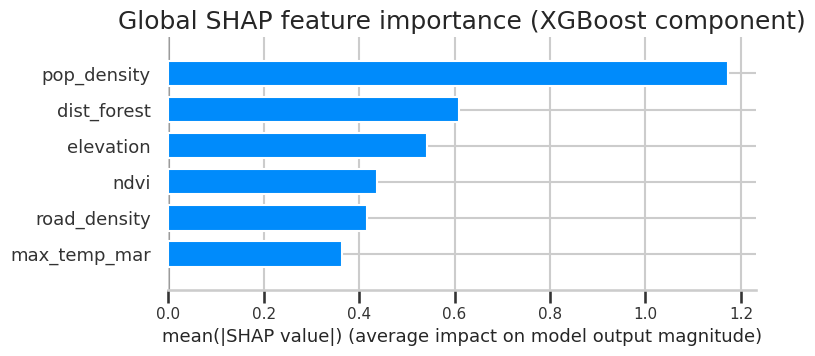

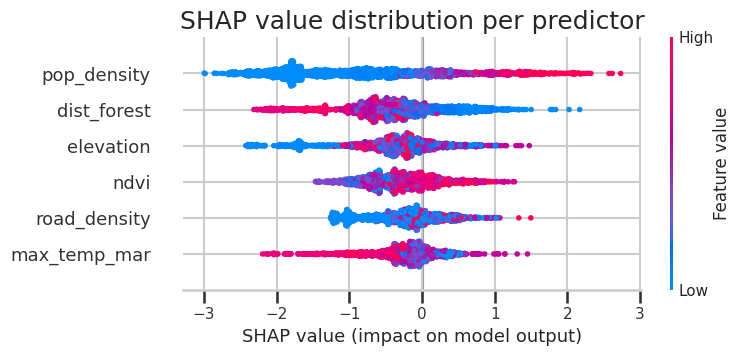

In [33]:
# 13.1 Compute SHAP values on the XGBoost component (TreeExplainer is fast)
explainer = shap.TreeExplainer(m_xg)
# Sample a manageable subset of the grid for SHAP (full grid is large)
n_shap = min(2000, grid_feats_s.shape[0])
shap_idx = np.random.RandomState(SEED).choice(grid_feats_s.shape[0], n_shap, replace=False)
shap_values = explainer.shap_values(grid_feats_s[shap_idx])
print(f"SHAP values shape: {shap_values.shape}")

# Global SHAP summary plot
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, grid_feats_s[shap_idx],
                   feature_names=final_predictors, show=False, plot_type="bar")
plt.title("Global SHAP feature importance (XGBoost component)")
plt.tight_layout(); plt.show()

# Beeswarm plot — individual SHAP values
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, grid_feats_s[shap_idx],
                   feature_names=final_predictors, show=False)
plt.title("SHAP value distribution per predictor")
plt.tight_layout(); plt.show()

In [34]:
# 14.1 Three alternative weighting schemes
def alt_weights(scheme):
    if scheme == "population_only":
        return lga_df["pop_density"].copy()
    if scheme == "ndvi_only":
        return lga_df["ndvi"] + 0.1
    if scheme == "forest_proximity_only":
        return 1.0 / np.maximum(lga_df["dist_forest"], 5.0)
    raise ValueError

scheme_rankings = {}
for scheme in ["population_only", "ndvi_only", "forest_proximity_only"]:
    w = alt_weights(scheme)
    share = w / w.sum()
    n_alt = np.round(share * (OGUN_CONFIRMED + OGUN_SUSPECTED)).astype(int)
    # Rank LGAs by allocated count
    rank = pd.Series(n_alt.values, index=lga_df["shapeName"]).rank(ascending=False)
    scheme_rankings[scheme] = rank

# Original (combined) ranking
orig_rank = pd.Series(lga_df["n_occurrence"].values,
                       index=lga_df["shapeName"]).rank(ascending=False)
scheme_rankings["combined_(original)"] = orig_rank

# Spearman rank correlation across schemes
from scipy.stats import spearmanr
schemes = list(scheme_rankings.keys())
corr_mat = np.zeros((len(schemes), len(schemes)))
for i, a in enumerate(schemes):
    for j, b in enumerate(schemes):
        rho, _ = spearmanr(scheme_rankings[a], scheme_rankings[b])
        corr_mat[i, j] = rho

corr_df = pd.DataFrame(corr_mat, index=schemes, columns=schemes)
print("=== Disaggregation-weight sensitivity: Spearman rank correlations ===")
print(corr_df.round(3))
print(f"\nMean off-diagonal correlation: {(corr_df.values.sum() - np.trace(corr_df.values)) / (corr_df.size - len(schemes)):.3f}")
print("Interpretation: > 0.7 indicates ranking is robust to disaggregation choice")

=== Disaggregation-weight sensitivity: Spearman rank correlations ===
                       population_only  ndvi_only  forest_proximity_only  \
population_only                  1.000     -0.495                 -0.058   
ndvi_only                       -0.495      1.000                  0.178   
forest_proximity_only           -0.058      0.178                  1.000   
combined_(original)              0.741     -0.225                  0.530   

                       combined_(original)  
population_only                      0.741  
ndvi_only                           -0.225  
forest_proximity_only                0.530  
combined_(original)                  1.000  

Mean off-diagonal correlation: 0.112
Interpretation: > 0.7 indicates ranking is robust to disaggregation choice


In [35]:
# 14.2 Visualise top-5 LGAs under each scheme (overlap test)
top5 = {scheme: r.sort_values().head(5).index.tolist() for scheme, r in scheme_rankings.items()}
print("=== Top-5 priority LGAs under each weighting scheme ===")
for scheme, top in top5.items():
    print(f"  {scheme:30s} -> {top}")
all_top = set()
for top in top5.values(): all_top.update(top)
common = set.intersection(*[set(t) for t in top5.values()])
print(f"\nUnion of top-5 across all schemes: {len(all_top)} LGAs")
print(f"Intersection (always-top-5):       {len(common)} LGAs -> {sorted(common)}")

=== Top-5 priority LGAs under each weighting scheme ===
  population_only                -> ['Ifo', 'Abeokuta South', 'Ewekoro', 'Remo North', 'Ikenne']
  ndvi_only                      -> ['Ijebu North East', 'Ado Odo/Ota', 'Ijebu East', 'Yewa South', 'Ijebu Ode']
  forest_proximity_only          -> ['Ijebu North East', 'Ijebu North', 'Odeda', 'Remo North', 'Ijebu Ode']
  combined_(original)            -> ['Abeokuta South', 'Remo North', 'Ikenne', 'Ijebu North East', 'Ifo']

Union of top-5 across all schemes: 12 LGAs
Intersection (always-top-5):       0 LGAs -> []


In [36]:
# 15.1 Reconstitute LGA suitability from §10 inputs (re-aggregate from boot_mean)
# (We compute again to make this section self-contained for the comparison narrative)
lga_compare = []
for _, row in ogun_lgas.iterrows():
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())], crs=ogun_lgas.crs)
    inside = pts.within(row.geometry).values & mask.ravel()
    if inside.sum() == 0: continue
    lga_compare.append({
        "LGA": row["shapeName"],
        "Mean suit": float(np.nanmean(boot_mean[inside[mask.ravel()]])),
        "n cells":   int(inside.sum()),
    })
lga_compare_df = pd.DataFrame(lga_compare)

ogun_overall_suit = lga_compare_df["Mean suit"].mean()
ANCHOR_RISK_BANDS = {"low": (0.0, 0.30), "medium": (0.30, 0.60), "high": (0.60, 1.0)}
def band(v):
    for k, (lo, hi) in ANCHOR_RISK_BANDS.items():
        if lo <= v < hi: return k
    return "high"
ogun_band = band(ogun_overall_suit)

print(f"Ogun State overall mean suitability: {ogun_overall_suit:.3f}")
print(f"Anchor paper (Arotolu et al. 2022)  : Ogun = MEDIUM risk")
print(f"This work                            : Ogun = {ogun_band.upper()} risk (mean suit = {ogun_overall_suit:.3f})")
agreement = ogun_band == "medium"
print(f"\nAgreement with anchor paper: {'YES' if agreement else 'NO — re-examine'}")
print()
# Which LGAs drive Ogun's overall classification?
print("LGAs driving Ogun's overall risk (top 5 highest suitability):")
print(lga_compare_df.sort_values("Mean suit", ascending=False).head(5).to_string(index=False))

Ogun State overall mean suitability: 0.227
Anchor paper (Arotolu et al. 2022)  : Ogun = MEDIUM risk
This work                            : Ogun = LOW risk (mean suit = 0.227)

Agreement with anchor paper: NO — re-examine

LGAs driving Ogun's overall risk (top 5 highest suitability):
             LGA  Mean suit  n cells
  Abeokuta South   0.680814       51
Ijebu North East   0.510195      121
      Remo North   0.499864      168
          Ikenne   0.416763      146
         Ewekoro   0.299470      508


In [37]:
# 16.1 Aggregate suitability per LGA
lga_priority = []
for _, row in ogun_lgas.iterrows():
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())], crs=ogun_lgas.crs)
    inside = pts.within(row.geometry).values
    mean_vals = mean_grid.ravel()[inside & mask.ravel()]
    std_vals  = std_grid.ravel()[inside & mask.ravel()]
    if len(mean_vals) == 0: continue
    lga_priority.append({
        "LGA": row["shapeName"],
        "Mean suitability": float(np.nanmean(mean_vals)),
        "Max suitability":  float(np.nanmax(mean_vals)),
        "Mean uncertainty": float(np.nanmean(std_vals)),
        "High-risk area (km²)": float(np.sum(mean_vals > 0.6) * (1.1**2)),  # cells > 0.6, ~1.1km cells
    })
lga_priority_df = pd.DataFrame(lga_priority).sort_values("Mean suitability", ascending=False)
print("=== Top 10 priority LGAs for Mpox surveillance and intervention ===")
print(lga_priority_df.head(10).round(3).to_string(index=False))

=== Top 10 priority LGAs for Mpox surveillance and intervention ===
             LGA  Mean suitability  Max suitability  Mean uncertainty  High-risk area (km²)
  Abeokuta South             0.681            0.830             0.114                 48.40
Ijebu North East             0.510            0.729             0.122                 37.51
      Remo North             0.500            0.745             0.122                 36.30
          Ikenne             0.417            0.732             0.092                 13.31
         Ewekoro             0.299            0.585             0.090                  0.00
             Ifo             0.294            0.625             0.104                  2.42
   Obafemi Owode             0.259            0.732             0.065                  6.05
       Ijebu Ode             0.238            0.495             0.072                  0.00
     Ijebu North             0.203            0.632             0.064                  2.42
           O

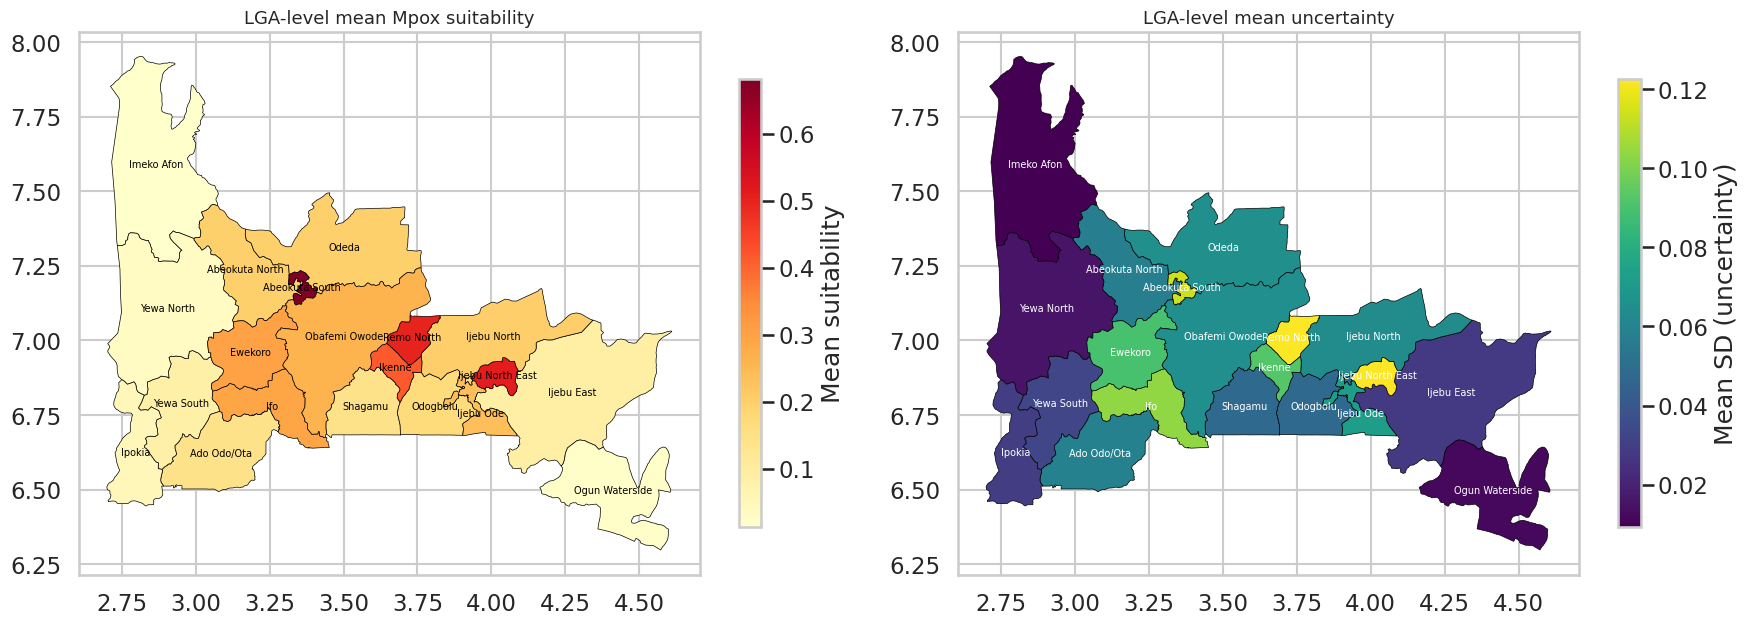

In [38]:
# 16.2 Visualise per-LGA priority
ogun_priority = ogun_lgas.merge(lga_priority_df, left_on="shapeName", right_on="LGA")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ogun_priority.plot(column="Mean suitability", ax=axes[0], legend=True, cmap="YlOrRd",
                    edgecolor="black", linewidth=0.5,
                    legend_kwds={"label": "Mean suitability", "shrink": 0.6})
axes[0].set_title("LGA-level mean Mpox suitability", fontsize=13)
for _, r in ogun_priority.iterrows():
    c = r.geometry.centroid
    axes[0].annotate(r["shapeName"], xy=(c.x, c.y), fontsize=7,
                     ha="center", va="center", color="black")

ogun_priority.plot(column="Mean uncertainty", ax=axes[1], legend=True, cmap="viridis",
                    edgecolor="black", linewidth=0.5,
                    legend_kwds={"label": "Mean SD (uncertainty)", "shrink": 0.6})
axes[1].set_title("LGA-level mean uncertainty", fontsize=13)
for _, r in ogun_priority.iterrows():
    c = r.geometry.centroid
    axes[1].annotate(r["shapeName"], xy=(c.x, c.y), fontsize=7,
                     ha="center", va="center", color="white")

plt.tight_layout(); plt.show()

In [39]:
# 17.1 Jenks-style natural breaks via quantiles (3-tier)
sus = lga_priority_df["Mean suitability"].values
breaks = np.quantile(sus, [0.0, 0.33, 0.67, 1.0])
def tier(v):
    if v >= breaks[2]: return "HIGH"
    if v >= breaks[1]: return "MEDIUM"
    return "LOW"
lga_priority_df["Risk tier"] = lga_priority_df["Mean suitability"].apply(tier)
print("=== Risk-tier breakdown ===")
print(lga_priority_df["Risk tier"].value_counts())
print()

surveillance_table = lga_priority_df[["LGA", "Mean suitability", "Mean uncertainty",
                                        "High-risk area (km²)", "Risk tier"]].copy()
surveillance_table["Recommended action"] = surveillance_table["Risk tier"].map({
    "HIGH":   "Active case finding monthly; vaccinate frontline HCWs; weekly RDT testing",
    "MEDIUM": "Quarterly active case finding; train DSNOs; bushmeat-trade monitoring",
    "LOW":    "Passive surveillance via routine IDSR; community awareness campaigns",
})
print("=== Tier-specific surveillance recommendations ===\n")
print(surveillance_table.round(3).to_string(index=False))

=== Risk-tier breakdown ===
Risk tier
HIGH      7
LOW       7
MEDIUM    6
Name: count, dtype: int64

=== Tier-specific surveillance recommendations ===

             LGA  Mean suitability  Mean uncertainty  High-risk area (km²) Risk tier                                                        Recommended action
  Abeokuta South             0.681             0.114                 48.40      HIGH Active case finding monthly; vaccinate frontline HCWs; weekly RDT testing
Ijebu North East             0.510             0.122                 37.51      HIGH Active case finding monthly; vaccinate frontline HCWs; weekly RDT testing
      Remo North             0.500             0.122                 36.30      HIGH Active case finding monthly; vaccinate frontline HCWs; weekly RDT testing
          Ikenne             0.417             0.092                 13.31      HIGH Active case finding monthly; vaccinate frontline HCWs; weekly RDT testing
         Ewekoro             0.299             0.090

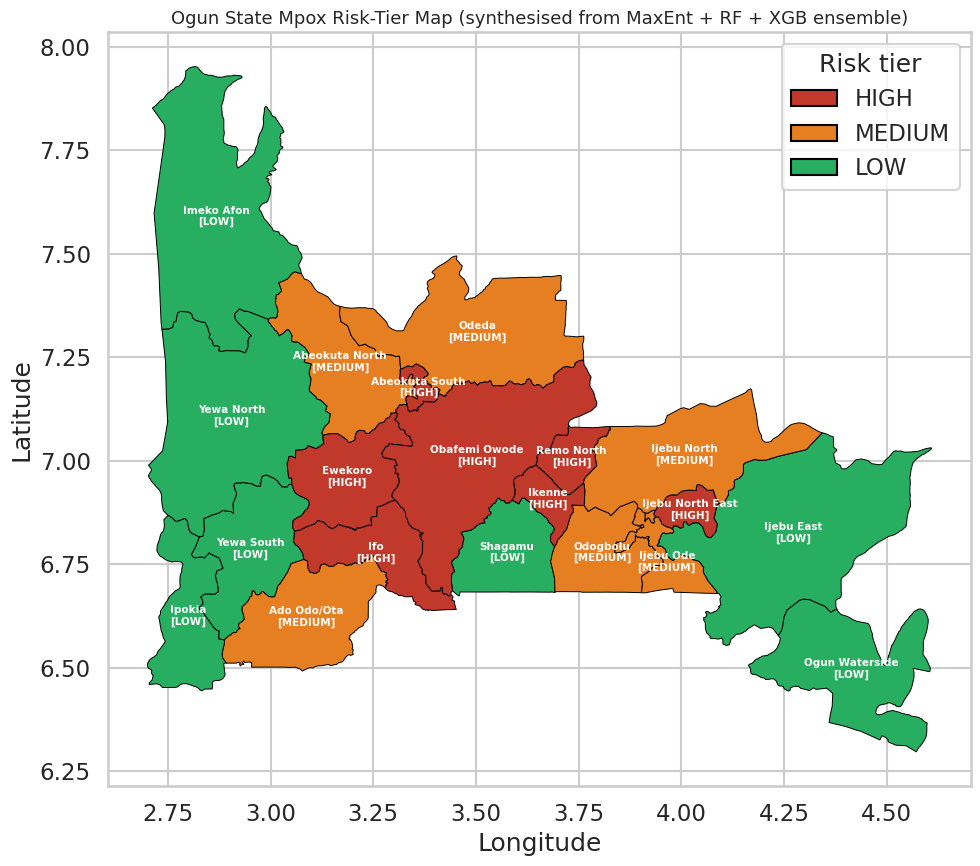

In [40]:
# 17.2 Final tier map
ogun_tiers = ogun_lgas.merge(lga_priority_df[["LGA", "Risk tier"]],
                              left_on="shapeName", right_on="LGA")
tier_colors = {"HIGH": "#c0392b", "MEDIUM": "#e67e22", "LOW": "#27ae60"}
ogun_tiers["color"] = ogun_tiers["Risk tier"].map(tier_colors)

fig, ax = plt.subplots(figsize=(11, 9))
ogun_tiers.plot(ax=ax, color=ogun_tiers["color"], edgecolor="black", linewidth=0.7)
for _, r in ogun_tiers.iterrows():
    c = r.geometry.centroid
    ax.annotate(f"{r['shapeName']}\n[{r['Risk tier']}]",
                xy=(c.x, c.y), fontsize=7.5, ha="center", va="center", color="white",
                fontweight="bold")
ax.set_title("Ogun State Mpox Risk-Tier Map (synthesised from MaxEnt + RF + XGB ensemble)",
             fontsize=13)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# Custom legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor="black", label=t) for t, c in tier_colors.items()]
ax.legend(handles=handles, loc="upper right", title="Risk tier")
plt.tight_layout(); plt.show()

In [41]:
# 18.0 Shared helper: allocation -> jittered points -> ensemble -> per-LGA suitability
# Reuses the exact modelling choices from Sections 4-9 (same predictors, scaler recipe,
# MaxEnt/RF/XGB settings, 2,000 background points) so the sub-models are comparable to
# the main ensemble. Fits a fresh StandardScaler per run (each run has its own dataset).
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler as _StdScaler

# --- Precompute, once: map each in-mask grid cell to its LGA (aligned to grid_feats rows)
_gx, _gy = xx[mask], yy[mask]                      # same C-order as predictors[k][mask]
_grid_pts = gpd.GeoSeries([Point(x, y) for x, y in zip(_gx, _gy)], crs=ogun_lgas.crs)
grid_lga = np.array([None] * len(_gx), dtype=object)
for _, _row in ogun_lgas.iterrows():
    _inside = _grid_pts.within(_row.geometry).values
    grid_lga[_inside] = _row["shapeName"]
print(f"Grid->LGA labels assigned for {np.sum(grid_lga != None):,}/{len(_gx):,} masked cells")

def gen_occ_points(alloc_counts, seed):
    """Generate within-LGA jittered occurrence points from an integer allocation
    (pd.Series indexed by shapeName). Mirrors Section 4.3."""
    rng = np.random.RandomState(seed)
    rows = []
    for _, r in ogun_lgas.iterrows():
        n = int(alloc_counts.get(r["shapeName"], 0))
        if n <= 0:
            continue
        minx, miny, maxx, maxy = r.geometry.bounds
        got = []
        while len(got) < n:
            cx = rng.uniform(minx, maxx, n * 5)
            cy = rng.uniform(miny, maxy, n * 5)
            for x, y in zip(cx, cy):
                if Point(x, y).within(r.geometry):
                    got.append((x, y))
                    if len(got) == n:
                        break
        rows += [{"lga": r["shapeName"], "lon": x, "lat": y} for x, y in got]
    df = pd.DataFrame(rows)
    return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]),
                            crs=ogun_lgas.crs)

def build_lga_suitability(alloc_counts, seed, n_background=2000):
    """Allocation -> points -> ensemble -> (per-LGA mean suitability Series, grid preds, models)."""
    occ = gen_occ_points(alloc_counts, seed)
    oe = sample_predictors(occ, predictors, xs, ys)[final_predictors].copy()
    oe["presence"] = 1
    _bgxy, biy, bix = sample_background(n_background, mask, xx, yy, seed=seed)
    be = pd.DataFrame({k: predictors[k][biy, bix] for k in final_predictors})
    be["presence"] = 0
    data = pd.concat([oe, be], ignore_index=True)
    sc = _StdScaler().fit(data[final_predictors].values)
    Xtr = sc.transform(data[final_predictors].values)
    ytr = data["presence"].values

    me = elapid.MaxentModel(feature_types=["linear", "quadratic", "hinge"],
                            transform="cloglog", tau=0.5).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed).fit(Xtr, ytr)
    xg = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           random_state=seed, n_jobs=-1, verbosity=0,
                           eval_metric="logloss").fit(Xtr, ytr)
    gs = sc.transform(grid_feats)
    p = (me.predict(gs) + rf.predict_proba(gs)[:, 1] + xg.predict_proba(gs)[:, 1]) / 3.0
    lga_suit = (pd.DataFrame({"lga": grid_lga, "suit": p})
                  .dropna(subset=["lga"]).groupby("lga")["suit"].mean())
    return lga_suit, p, {"maxent": me, "rf": rf, "xgb": xg, "scaler": sc, "occ": occ}

def tiers_from(series):
    """Tertile HIGH/MEDIUM/LOW, matching Section 17.1."""
    b = np.quantile(series.values, [0.0, 0.33, 0.67, 1.0])
    return series.apply(lambda v: "HIGH" if v >= b[2] else ("MEDIUM" if v >= b[1] else "LOW"))

# Allocations reused below (from Section 4.2 lga_df)
alloc_confirmed = pd.Series(lga_df["n_confirmed"].values, index=lga_df["shapeName"])
alloc_suspected = pd.Series(lga_df["n_suspected"].values, index=lga_df["shapeName"])
alloc_combined  = pd.Series(lga_df["n_occurrence"].values, index=lga_df["shapeName"])
print(f"Allocated points -> confirmed-only: {int(alloc_confirmed.sum())}, "
      f"suspected-only: {int(alloc_suspected.sum())}, combined: {int(alloc_combined.sum())}")

Grid->LGA labels assigned for 13,682/13,682 masked cells
Allocated points -> confirmed-only: 40, suspected-only: 149, combined: 189


In [42]:
# 18.1 CONFIRMED-ONLY SENSITIVITY (Reviewer 1, comment 3)
# Re-run the full pipeline using ONLY the 40 confirmed-case allocation, and compare the
# resulting LGA priority ranking to the combined (191-case) model.
suit_confirmed, _, _ = build_lga_suitability(alloc_confirmed, seed=SEED)
suit_combined,  _, _ = build_lga_suitability(alloc_combined,  seed=SEED)

cmp_df = pd.concat([suit_confirmed.rename("confirmed_only"),
                    suit_combined.rename("combined")], axis=1).dropna()
rho_all, p_all = spearmanr(cmp_df["confirmed_only"], cmp_df["combined"])

t_conf = tiers_from(cmp_df["confirmed_only"])
t_comb = tiers_from(cmp_df["combined"])
high_agree = int(((t_conf == "HIGH") & (t_comb == "HIGH")).sum())
low_agree  = int(((t_conf == "LOW")  & (t_comb == "LOW")).sum())
n_high = int((t_comb == "HIGH").sum()); n_low = int((t_comb == "LOW").sum())

top5_conf = set(cmp_df["confirmed_only"].sort_values(ascending=False).head(5).index)
top5_comb = set(cmp_df["combined"].sort_values(ascending=False).head(5).index)
rho_top5, _ = spearmanr(cmp_df.loc[list(top5_comb), "confirmed_only"],
                        cmp_df.loc[list(top5_comb), "combined"])

print("=== 18.1 Confirmed-only vs combined LGA suitability ===")
print(f"LGAs compared:                         {len(cmp_df)}")
print(f"Spearman rho (all LGAs):               {rho_all:.3f}  (p={p_all:.3g})")
print(f"Spearman rho (top-5 combined LGAs):    {rho_top5:.3f}")
print(f"HIGH-tier concordance:                 {high_agree}/{n_high}")
print(f"LOW-tier concordance:                  {low_agree}/{n_low}")
print(f"Top-5 overlap:                         {len(top5_conf & top5_comb)}/5 "
      f"-> {sorted(top5_conf & top5_comb)}")
display(cmp_df.assign(tier_confirmed=t_conf, tier_combined=t_comb)
             .sort_values("combined", ascending=False).round(3))

=== 18.1 Confirmed-only vs combined LGA suitability ===
LGAs compared:                         20
Spearman rho (all LGAs):               0.979  (p=7.15e-14)
Spearman rho (top-5 combined LGAs):    0.900
HIGH-tier concordance:                 7/7
LOW-tier concordance:                  7/7
Top-5 overlap:                         4/5 -> ['Abeokuta South', 'Ijebu North East', 'Ikenne', 'Remo North']


,confirmed_only,combined,tier_confirmed,tier_combined
lga,,,,
Abeokuta South,0.495,0.778,HIGH,HIGH
Ijebu North East,0.361,0.540,HIGH,HIGH
Remo North,0.366,0.532,HIGH,HIGH
Ikenne,0.251,0.416,HIGH,HIGH
Ifo,0.179,0.301,HIGH,HIGH
Ewekoro,0.202,0.295,HIGH,HIGH
Obafemi Owode,0.196,0.247,HIGH,HIGH
Ijebu Ode,0.093,0.227,MEDIUM,MEDIUM
Abeokuta North,0.140,0.204,MEDIUM,MEDIUM


In [43]:
# 18.2 RETROSPECTIVE TEMPORAL-SPLIT VALIDATION (Reviewer 1, comment 7)
# Train the ensemble on the 40 confirmed 2022 cases (early); hold out the 151 suspected
# 2022-2024 cases (later). Test whether the 2022-only model predicts where later cases fell.
suit_2022, grid_2022, models_2022 = build_lga_suitability(alloc_confirmed, seed=SEED)
me22, rf22, xg22, sc22 = (models_2022["maxent"], models_2022["rf"],
                          models_2022["xgb"], models_2022["scaler"])

# Held-out (later) suspected occurrence points
susp_gdf = gen_occ_points(alloc_suspected, seed=SEED + 999)
susp_env = sample_predictors(susp_gdf, predictors, xs, ys)[final_predictors]
_bgxy, hiy, hix = sample_background(2000, mask, xx, yy, seed=SEED + 999)
hbg_env = pd.DataFrame({k: predictors[k][hiy, hix] for k in final_predictors})

Xh = sc22.transform(pd.concat([susp_env, hbg_env], ignore_index=True).values)
yh = np.r_[np.ones(len(susp_env)), np.zeros(len(hbg_env))]
ph = (me22.predict(Xh) + rf22.predict_proba(Xh)[:, 1] + xg22.predict_proba(Xh)[:, 1]) / 3.0
auc_hold = roc_auc_score(yh, ph)
ap_hold  = average_precision_score(yh, ph)

# Per-LGA: do 2022-model suitabilities track where the later suspected cases concentrated?
susp_counts = alloc_suspected.reindex(suit_2022.index).fillna(0)
rho_t, p_t = spearmanr(suit_2022.values, susp_counts.values)

# Tier concordance: 2022-only model vs full combined model (Section 17)
full_tier = (lga_priority_df.set_index("LGA")["Risk tier"]
             if "Risk tier" in lga_priority_df.columns else tiers_from(suit_combined))
tier_2022 = tiers_from(suit_2022)
common = suit_2022.index.intersection(full_tier.index)
high_c = int(((tier_2022.reindex(common) == "HIGH") & (full_tier.reindex(common) == "HIGH")).sum())
low_c  = int(((tier_2022.reindex(common) == "LOW")  & (full_tier.reindex(common) == "LOW")).sum())

print("=== 18.2 Retrospective temporal-split validation ===")
print(f"Train = 40 confirmed (2022); holdout = 151 suspected (2022-2024)")
print(f"Holdout discrimination  AUC:           {auc_hold:.3f}")
print(f"Holdout                 AUC-PR:        {ap_hold:.3f}")
print(f"Per-LGA Spearman (2022 suit vs later suspected counts): {rho_t:.3f} (p={p_t:.3g})")
print(f"HIGH-tier concordance (2022 vs full):  {high_c}/{int((full_tier.reindex(common)=='HIGH').sum())}")
print(f"LOW-tier concordance  (2022 vs full):  {low_c}/{int((full_tier.reindex(common)=='LOW').sum())}")

=== 18.2 Retrospective temporal-split validation ===
Train = 40 confirmed (2022); holdout = 151 suspected (2022-2024)
Holdout discrimination  AUC:           0.792
Holdout                 AUC-PR:        0.280
Per-LGA Spearman (2022 suit vs later suspected counts): 0.975 (p=3.77e-13)
HIGH-tier concordance (2022 vs full):  7/7
LOW-tier concordance  (2022 vs full):  7/7
